<a href="https://colab.research.google.com/github/castimax/Chatbot-medico/blob/main/workshop-unir-2026/taller_ia_salud_colab_v5_2_ALUMNOS_FINAL_FARMAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div style="text-align:center; margin:8px 0 20px 0;">
  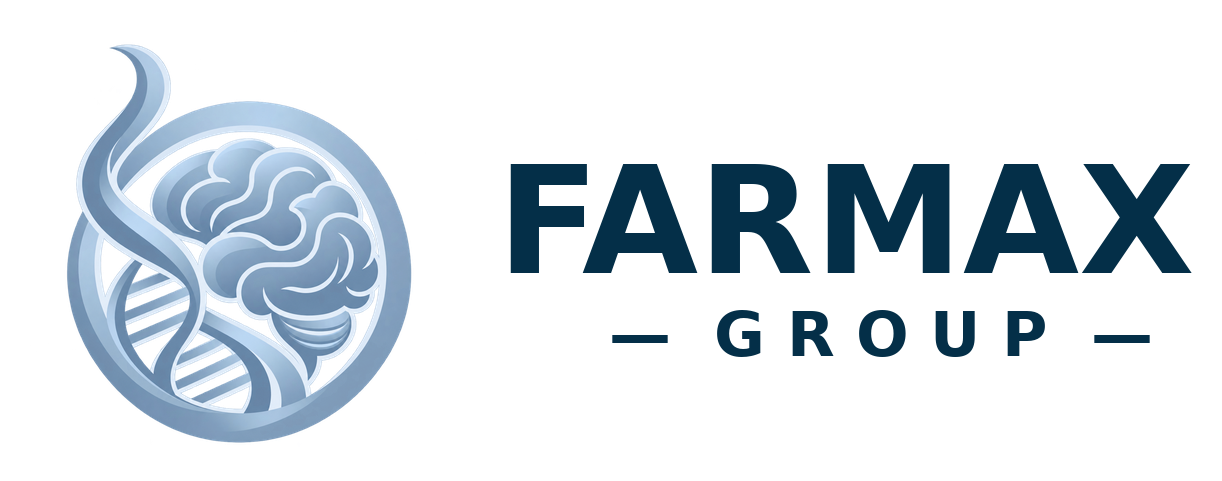
  <div style="margin-top:6px; font-size:12px; color:#496273;">
    Material docente · IA aplicada a la salud
  </div>
</div>

# 🏥 Taller práctico: IA en salud
## Asistente clínico con RAG + multimodal (Colab)

| | |
|:--|:--|
| **Ponente** | Ph.D. Maximiliano Hernández S. |
| **Fecha** | Jueves **1 de octubre de 2026**, **19:00–20:00** (Europe/Madrid) |
| **Audiencia** | **DIGESA** · **DIRENF** · **SECLIPA** (+ FUNDAE) — gestión sanitaria, dirección de enfermería y seguridad clínica |
| **Nivel técnico** | Ninguno previo. Aprendemos Colab, API y Secrets **antes** de las demos. |
| **Motores** | **Gemini / OpenAI / DeepSeek** — elegid el que tengáis configurado y validado para la demo |
| **Casos estrella** | Quirónsalud **Scribe** · Mayo Clinic **Nurse VA** · Son Llàtzer **BIAlert Sepsis** |
| **Mensaje clave** | *«La IA potencia al profesional, no lo sustituye.»* |

> ### ✅ Demo live-proof · **1 oct 2026** (ensayo en aula)
>
> | En directo | Qué hacer |
> |------------|-----------|
> | **Gemini** | `gemini-3.8-flash` · opción gratuita para empezar, con cuota limitada. |
> | **OpenAI** | `gpt-5.6-luna` · de pago; buena opción para comparar texto + imagen. |
> | **DeepSeek** | `deepseek-flash` · de pago y muy económico; también acepta imagen. |
> | **Embeddings** | Con DeepSeek: **Gemini** o **TF‑IDF** local; OpenAI embeddings = **último recurso**. |

> ### 🛡️ Banner ético — leedlo una vez y recordadlo todo el taller
>
> | Principio | Qué implica hoy |
> |-----------|-----------------|
> | Supervisión humana | La IA **orienta**; el profesional **decide y firma**. |
> | Privacidad | **Nunca** datos reales de pacientes en este notebook ni en chats públicos. |
> | Trazabilidad | Preferimos respuestas **ancladas a documentos** (RAG) frente a «memoria» del modelo. |
> | Transparencia | Si el modelo no sabe o el documento no cubre algo, debe **decirlo**. |
> | Cumplimiento | AI Act UE / gobernanza del centro: piloto solo con **aprobación de TI / privacidad**. |

Este notebook es **regalo didáctico**: cada asistente configura **su propia** clave API en **Secrets de Colab**. **No hay claves embebidas** en el archivo. Por defecto usamos **Gemini con cuota gratuita limitada**; también podéis probar OpenAI o DeepSeek.

> 📺 **Seguís en Zoom:** cada bloque grande empieza con una línea `---` y un título numerado. Antes de cada celda importante veréis un banner naranja **«▶️ EJECUTAD ESTA CELDA»**.


---
## © Autoría y licencia de uso

**© 2026 Maximiliano Hernández S.**

Material docente preparado para el taller **«Creación y Uso de Chatbots Médicos con IA»**.

Este notebook se distribuye bajo licencia **Creative Commons Atribución-NoComercial 4.0 Internacional (CC BY-NC 4.0)**.

- Se permite **copiar, compartir y adaptar** el material con fines no comerciales.
- Debe mantenerse la **atribución al autor** e indicarse si se realizan cambios.
- La licencia no cubre marcas, servicios, modelos, imágenes o materiales de terceros, que conservan sus propias condiciones de uso.
- **No contiene claves API ni datos reales de pacientes.** Cada usuario debe configurar sus propias credenciales en *Secrets* de Google Colab.

Licencia: https://creativecommons.org/licenses/by-nc/4.0/deed.es
---


---

# 📋 Agenda (~60 min)

---

| Min | Bloque | Qué haremos |
|-----|--------|-------------|
| 0–8 | Contexto y Colab | Qué es Colab, qué es una API, cómo guardar **vuestra** clave con seguridad |
| 8–18 | Setup | Elegir proveedor (**Gemini / OpenAI / DeepSeek**) y comprobar credenciales, instalar, inicializar |
| 18–30 | RAG + fuente pública | Guía HTA didáctica → trocear/indexar · **pipeline** (+ router opc.) · **Creador Mermaid** |
| 30–42 | **Demo 1 — A vs B** | Misma pregunta clínica **sin RAG** vs **con RAG** (+ modo C opcional simulado) |
| 42–50 | **Demo 2 — Multimodal** | Imagen Wikimedia (atribución) + lenguaje prudente |
| 50–56 | Ética · RGPD · cierre | Confidencialidad, AI Act, checklist; APA y reutilización |
| 56–60 | Q&A | Cómo llevarlo al hospital **con TI** |

**Hilo de los casos estrella (charla + este Colab):** DIGESA → Quirónsalud *Scribe* · DIRENF → Mayo Clinic *Nurse Virtual Assistant* · SECLIPA → Son Llàtzer *BIAlert Sepsis*.

**Objetivo de salida:** entender el flujo y decidir con criterio — no «programar como ingenieros».


---

# ⭐ Casos reales de referencia

---

Tabla compacta para orientar el debate. Los **tres casos, sus caveats, preguntas y referencias están embebidos en este notebook** y se desarrollan también en las diapositivas de la charla.

| Pista | Caso | Por qué en 1 línea | Caveat |
|-------|------|--------------------|--------|
| **DIGESA** | Quirónsalud · **Scribe** | Escriba ambiental LLM a escala en consultas (ES); borrador → clínico valida | Sin validación humana **no** entra en la historia |
| **DIRENF** | Mayo Clinic · **Nurse Virtual Assistant** | RAG/chatbot «por y para enfermeras» en la HCE (transferible a guías de unidad) | Nunca sustituye juicio ni doble verificación de medicación |
| **SECLIPA** | Son Llàtzer · **BIAlert Sepsis** | Alerta precoz de sepsis (CE IIa) + impacto medible en hospital público ES | Humano valida; **nunca** automatizar tratamiento |

> 🩺 En Demo 1 tenéis **preguntas de ejemplo** etiquetadas por pista. Con la guía HTA didáctica, si «no consta» — es una lección de gobernanza: el RAG solo sabe lo que le dais.


---

# A · Fundamentos (antes de ejecutar código)

Colab · API · Cómo crear la clave · Secrets

---


## A1 · ¿Qué es Google Colab?

**Google Colaboratory (Colab)** es un cuaderno (*notebook*) que se abre en el **navegador**. No hace falta instalar Python en el portátil del hospital.

### Cómo usarlo (3 gestos)

1. **Ejecutar una celda** → clic en ▶ o `Mayús + Enter`.
2. **El orden importa** → la primera vez, ejecutad de **arriba abajo** (como un protocolo).
3. **Runtime** → menú *Entorno de ejecución*: si algo falla de forma rara, *Reiniciar sesión* y volved a ejecutar desde el principio.

| Concepto | Analogía clínica |
|----------|------------------|
| Celda Markdown | Nota explicativa / consentimiento informado |
| Celda de código | Paso del protocolo que «hace» algo |
| Secrets (🔑) | Armario con llave: la API key **no** va en el texto del protocolo |

> 💡 Si Colab pide permiso de red, aceptad solo lo necesario para el taller. Para estas demos basta CPU + Internet.


## A2 · ¿Qué es una API? ¿Y una API key?

### API (*Application Programming Interface*)
Es un **canal formal** para pedir un servicio a otro sistema.

**Analogía clínica:** llamáis a un **servicio de interconsulta**. No entráis en su despacho a revolver historias: enviáis una petición estructurada y recibís una respuesta. La API es ese mostrador.

### API key
Es la **credencial** que identifica *quién* pide el servicio (y a qué cuenta se factura).

| Sí | No |
|----|----|
| Guardarla en **Secrets de Colab** o en variables de entorno locales | Pegarla en el chat, en el correo, en un PDF o en GitHub |
| Usar **vuestra** clave (o la del laboratorio docente) | Compartir la clave del compañero o del ponente |
| Revocarla si se filtra | Dejarla escrita en una celda «para no olvidarla» |

> ⚠️ Las claves suelen empezar por patrones del tipo `sk-…`. **Nunca** las copiéis a este notebook. Si veis una clave en una celda, **borradla** y rotad la clave en el panel del proveedor.


## A3 · Cómo crear **tu propia** clave (Gemini con cuota gratuita limitada, OpenAI y DeepSeek)

En este taller basta con **un proveedor**. El notebook tiene un **desplegable**: elegís Gemini, OpenAI o DeepSeek sin editar código.

### A) Gemini — **opción gratuita para empezar** (~2 minutos)

1. Entrad en **Google AI Studio**: [aistudio.google.com](https://aistudio.google.com).
2. Iniciad sesión con vuestra cuenta de Google.
3. Pulsad **Get API key / Obtener clave de API**.
4. Cread una clave y guardadla en **Secrets de Colab**.
5. Para este taller usamos `gemini-3.8-flash` (texto + imagen) y `gemini-embedding-001` para RAG.

> ⚠️ El nivel gratuito tiene **cuotas**. Es ideal para practicar en casa, pero en una sesión con muchas llamadas puede aparecer `429 quota/rate limit`.

> 📺 En directo: no hacemos llamadas de “prueba” al inicializar; guardamos la cuota para las demos reales.


### B) OpenAI — API de pago

1. Entrad en **OpenAI Platform** (`platform.openai.com`).
2. Cread una API key y guardadla como `OPENAI_API_KEY`.
3. Revisad **billing / límites**: la API es independiente de ChatGPT Plus.

**Modelo docente por defecto:** `gpt-5.6-luna` para texto **y** visión. Es el modelo actual de bajo coste de la familia GPT‑5.6. Para embeddings RAG usamos `text-embedding-3-small`.

> Si ya tenéis Secrets antiguos llamados `OPENAI_ANSWER_MODEL` y `OPENAI_VISION_MODEL`, el notebook **los detecta y los muestra como referencia**, pero no los usa por defecto para evitar que un nombre antiguo rompa la demo. Hay un interruptor avanzado para respetarlos si queréis probarlos.

### C) DeepSeek — API de pago, coste bajo

1. Entrad en **DeepSeek Platform** (`platform.deepseek.com`).
2. Generad una API key y guardadla como `DEEPSEEK_API_KEY`.
3. Revisad saldo / billing.

**Modelo docente por defecto:** `deepseek-flash` (texto + visión). `deepseek-v4-pro` queda como opción avanzada, no necesaria en el taller.

> El Secret `DEEPSEEK_OCR_MODEL` que algunos tenéis de proyectos anteriores **no se usa** en este notebook.

> 💳 Para aprender no necesitáis comprar los tres: **Gemini permite empezar gratis**. OpenAI y DeepSeek sirven para comparar proveedores cuando tengáis saldo.


## A4 · Guardar la clave en **Secrets de Colab** (clic a clic)

Hacedlo **antes** de ejecutar la celda de inicialización.

1. Panel izquierdo → **🔑 Secrets / Secretos**.
2. Cread el nombre exacto y pegad vuestra clave.
3. Activad **Acceso desde el cuaderno / Notebook access**.

| Secret exacto | Uso en V5.2 |
|---|---|
| `GOOGLE_API_KEY` **o** `GEMINI_API_KEY` | Gemini (el notebook prioriza `GOOGLE_API_KEY`) |
| `OPENAI_API_KEY` | OpenAI |
| `DEEPSEEK_API_KEY` | DeepSeek |
| `OPENAI_ANSWER_MODEL` | Opcional / legado: solo referencia o override avanzado |
| `OPENAI_VISION_MODEL` | Opcional / legado: solo referencia o override avanzado |

**No necesitáis activar** `GOOGLE_API_KEY_1`, `DEEPSEEK_OCR_MODEL`, Groq, Hugging Face, Serper, X/Twitter ni otros Secrets para este taller.

> ✅ El notebook nunca imprime el valor de una API key. Solo informa de si la clave está **disponible**, **sin acceso** o **ausente**.


---

# B · Setup · Instalar e inicializar

Dependencias → proveedor → cliente API

---


## B1 · Instalar dependencias

Ejecutad la celda siguiente **una vez** al empezar la sesión de Runtime (puede tardar **1–2 min**).

Usamos `-q` (salida más limpia). Si algo falla, quitad `-q` temporalmente para ver el error completo.

| Paquete | Para qué |
|---------|----------|
| `google-genai` | Cliente **Gemini** (texto, visión y embeddings) — opción con **cuota gratuita limitada** del taller |
| `openai` | Cliente OpenAI y DeepSeek (compatible) |
| `langchain` + `langchain-community` + `langchain-openai` | Orquestación RAG didáctica |
| `faiss-cpu` | Índice vectorial local |
| `pypdf` | Lectura opcional de PDF |
| `pillow` + `requests` | Imagen de demostración |
| `tiktoken` | Utilidad de tokens (ecosistema OpenAI) |


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda:** instalación de paquetes (1–2 min).


In [ ]:
# Helper Mermaid robusto para Google Colab
# Los diagramas principales tienen fallback LOCAL con Graphviz.
# Para un Mermaid editado por vosotros, intenta mermaid.ink y después Kroki.

import base64
import shutil
import subprocess
import requests
from IPython.display import SVG, display

DOT_FALLBACKS = {
    "Pipeline RAG": r"""
digraph G {
  rankdir=LR;
  graph [bgcolor="transparent", pad=0.2, nodesep=0.45, ranksep=0.65];
  node [shape=box, style="rounded", fontname="Arial", fontsize=11];
  edge [fontname="Arial", fontsize=10];
  Docs [label="Documentos / guía"];
  Chunks [label="Chunks"];
  Emb [label="Modelo de embeddings"];
  Vec [label="Vectores"];
  FAISS [label="FAISS / índice vectorial", shape=cylinder];
  Pregunta [label="Pregunta del usuario"];
  Chain [label="Cadena RAG"];
  LLM [label="LLM · Gemini / OpenAI / DeepSeek"];
  Resp [label="Respuesta con contexto"];
  Docs -> Chunks -> Emb -> Vec -> FAISS;
  Pregunta -> Chain;
  Chain -> FAISS [label="búsqueda semántica"];
  FAISS -> Chain [label="chunks recuperados"];
  Chain -> LLM -> Resp;
}
""",
    "Router Streamlit / TFM": r"""
digraph G {
  rankdir=TB;
  graph [bgcolor="transparent", pad=0.2];
  node [shape=box, style="rounded", fontname="Arial", fontsize=10.5];
  edge [fontname="Arial", fontsize=9.5];
  U [label="Usuario"]; UI [label="Interfaz Streamlit"]; API [label="FastAPI"];
  TR1 [label="Traducir ES → EN"]; AG [label="Agente personalizado"];
  R [label="Tipo de pregunta", shape=diamond];
  W [label="Wikipedia"]; M [label="Documentos médicos / RAG"]; A [label="ArXiv"];
  COMP [label="Compilar resultados"]; LLM [label="LLM Ollama"];
  TR2 [label="Traducir EN → ES"]; OUT [label="Respuesta en Streamlit"];
  EXP [label="Expansión: fuentes usadas"];
  U -> UI -> API -> TR1 -> AG -> R;
  R -> W [label="General"]; R -> M [label="Médica específica"]; R -> A [label="Estudios científicos"];
  W -> COMP; M -> COMP; A -> COMP;
  COMP -> LLM -> TR2 -> OUT -> EXP;
}
""",
    "1 · Flujo de paciente": r"""
digraph G {
  rankdir=TB; graph [bgcolor="transparent"];
  node [shape=box, style="rounded", fontname="Arial", fontsize=10.5];
  edge [fontname="Arial", fontsize=9.5];
  T [label="Triage"]; V [label="Valoración clínica"]; D [label="Decisión", shape=diamond];
  S [label="Seguimiento ambulatorio"]; I [label="Derivación / ingreso"]; C [label="Cierre / registro"];
  T -> V -> D; D -> S [label="Alta / seguimiento"]; D -> I [label="Ingreso / interconsulta"];
  S -> C; I -> C;
}
""",
    "2 · Calidad / seguridad": r"""
digraph G {
  rankdir=LR; graph [bgcolor="transparent"];
  node [shape=box, style="rounded", fontname="Arial", fontsize=10.5];
  E [label="Evento / incidente"]; A [label="Análisis causa-raíz"];
  C [label="Acción correctiva"]; D [label="Cierre y difusión"];
  E -> A -> C -> D;
}
""",
    "3 · Pipeline RAG simplificado": r"""
digraph G {
  rankdir=LR; graph [bgcolor="transparent"];
  node [shape=box, style="rounded", fontname="Arial", fontsize=10.5];
  Doc [label="Guía / protocolo"]; Ch [label="Chunks"]; Emb [label="Embeddings"];
  Ix [label="Índice FAISS", shape=cylinder]; P [label="Pregunta"]; Rag [label="Cadena RAG"];
  LLM [label="LLM"]; R [label="Respuesta auditada"];
  Doc -> Ch -> Emb -> Ix; P -> Rag; Rag -> Ix [label="búsqueda"]; Ix -> Rag [label="contexto"];
  Rag -> LLM -> R;
}
"""
}

def _mostrar_dot_local(dot):
    if not shutil.which("dot"):
        return False
    try:
        p = subprocess.run(
            ["dot", "-Tsvg"],
            input=dot.encode("utf-8"),
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            timeout=15,
            check=True,
        )
        display(SVG(p.stdout.decode("utf-8")))
        return True
    except Exception:
        return False

def mostrar_mermaid(codigo: str, titulo: str | None = None):
    codigo = codigo.strip()
    if titulo:
        print(f"\n🧭 {titulo}")

    # A) Diagramas fijos del taller: render local, sin depender de Internet.
    if titulo in DOT_FALLBACKS and _mostrar_dot_local(DOT_FALLBACKS[titulo]):
        return True

    # B) Mermaid editable: mermaid.ink.
    try:
        encoded = base64.urlsafe_b64encode(codigo.encode("utf-8")).decode("ascii")
        r = requests.get(f"https://mermaid.ink/svg/{encoded}", timeout=20)
        r.raise_for_status()
        if "<svg" not in r.text.lower():
            raise RuntimeError("La respuesta no contiene SVG.")
        display(SVG(r.text))
        return True
    except Exception as exc1:
        print(f"⚠️ Renderer Mermaid 1 no disponible ({type(exc1).__name__}).")

    # C) Respaldo: Kroki.
    try:
        payload = {
            "diagram_source": codigo,
            "diagram_type": "mermaid",
            "output_format": "svg",
        }
        r = requests.post("https://kroki.io/", json=payload, timeout=20)
        if not r.ok:
            raise RuntimeError(f"HTTP {r.status_code}: {(r.text or '')[:300]}")
        display(SVG(r.text))
        return True
    except Exception as exc2:
        print(f"⚠️ Renderer Mermaid 2 no disponible ({type(exc2).__name__}).")
        print("   Continuamos con el código Mermaid:")
        print(codigo)
        return False

print("✅ Diagramas del taller: render local Graphviz. Mermaid editable: doble renderer web.")


## B2 · Elegir proveedor e inicializar

### Desplegable docente

La celda siguiente muestra un **desplegable de Colab**. No hace falta editar código:

- **Gemini · `gemini-3.8-flash`** — gratis con cuota limitada.
- **OpenAI · `gpt-5.6-luna`** — de pago, bajo coste dentro de GPT‑5.6.
- **DeepSeek · `deepseek-flash`** — de pago y muy económico.

La inicialización **no consume tokens**: solo comprueba si el Secret puede leerse y prepara el cliente. Las llamadas reales empiezan en las demos.

### Secrets antiguos de OpenAI

Si vuestro Colab ya contiene `OPENAI_ANSWER_MODEL` o `OPENAI_VISION_MODEL`, se muestran como referencia. Por defecto usamos modelos actuales. El checkbox avanzado `USAR_MODELOS_OPENAI_GUARDADOS` permite probar los nombres antiguos conscientemente.

> 📺 Para comparar proveedores, más abajo hay una celda opcional que ejecuta **la misma pregunta** con todas las claves disponibles.


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda 1/2:** configuración + lectura de Secrets + cliente.


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda 2/2:** funciones `llamar_chat` y `llamar_vision` (obligatoria).


In [ ]:
#@title B2 · Selecciona el motor de IA
MOTOR_IA = "OpenAI · gpt-5.6-luna (de pago)" #@param ["Gemini · gemini-3.8-flash (cuota gratuita limitada)", "OpenAI · gpt-5.6-luna (de pago)", "DeepSeek · deepseek-flash (de pago, bajo coste)"]

# IMPORTANTE:
# False = usar los modelos actuales definidos en este notebook.
# True = usar OPENAI_ANSWER_MODEL / OPENAI_VISION_MODEL antiguos guardados en Secrets.
USAR_MODELOS_OPENAI_GUARDADOS = False #@param {type:"boolean"}

import os
from pathlib import Path


# ============================================================================
# 1 · MOTOR SELECCIONADO
# ============================================================================

MAPA_MOTORES = {
    "Gemini · gemini-3.8-flash (cuota gratuita limitada)": "gemini",
    "OpenAI · gpt-5.6-luna (de pago)": "openai",
    "DeepSeek · deepseek-flash (de pago, bajo coste)": "deepseek",
}

PROVEEDOR = MAPA_MOTORES[MOTOR_IA]


# ============================================================================
# 2 · DETECTAR SI ESTAMOS EN GOOGLE COLAB
# ============================================================================

EN_COLAB = False

try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False


# ============================================================================
# 3 · LEER SECRETS SIN MOSTRAR NUNCA SU VALOR
# ============================================================================

def estado_y_valor_secreto(nombre: str):
    """
    Devuelve:
        ("ok", valor)
        ("sin_acceso", None)
        ("ausente", None)

    Nunca imprime la API key.
    """

    if EN_COLAB:
        try:
            from google.colab import userdata

            valor = userdata.get(nombre)

            if valor:
                return "ok", str(valor).strip()

            return "ausente", None

        except Exception as exc:

            nombre_exc = type(exc).__name__.lower()
            texto = str(exc).lower()

            if (
                "access" in nombre_exc
                or "access" in texto
                or "notebook" in texto
            ):
                return "sin_acceso", None

            return "ausente", None

    valor = os.environ.get(nombre)

    if valor:
        return "ok", valor.strip()

    return "ausente", None


def leer_secreto(nombre: str):
    return estado_y_valor_secreto(nombre)[1]


def leer_secreto_cualquiera(nombres):

    for nombre in nombres:

        estado, valor = estado_y_valor_secreto(nombre)

        if estado == "ok" and valor:
            return valor, nombre

    return None, None


# ============================================================================
# 4 · NOMBRES EXACTOS DE LOS SECRETS
# ============================================================================

SECRETOS_API = {

    "gemini": [
        "GOOGLE_API_KEY",
        "GEMINI_API_KEY",
    ],

    "openai": [
        "OPENAI_API_KEY",
    ],

    "deepseek": [
        "DEEPSEEK_API_KEY",
    ],
}


# ============================================================================
# 5 · MODELOS DEL TALLER
# ============================================================================

MODELOS = {

    "gemini": {
        "chat": "gemini-3.8-flash",
        "vision": "gemini-3.8-flash",
        "embeddings": "gemini-embedding-001",
    },

    "openai": {
        "chat": "gpt-5.6-luna",
        "vision": "gpt-5.6-luna",
        "embeddings": "text-embedding-3-small",
    },

    "deepseek": {
        "chat": "deepseek-flash",
        "vision": "deepseek-flash",
        "embeddings": None,
        "base_url": "https://api.deepseek.com",
    },
}


# ============================================================================
# 6 · SECRETS ANTIGUOS DE MODELOS OPENAI
#     Solo se usan si marcas manualmente el checkbox = True
# ============================================================================

OPENAI_ANSWER_MODEL_GUARDADO = leer_secreto(
    "OPENAI_ANSWER_MODEL"
)

OPENAI_VISION_MODEL_GUARDADO = leer_secreto(
    "OPENAI_VISION_MODEL"
)


if USAR_MODELOS_OPENAI_GUARDADOS:

    if OPENAI_ANSWER_MODEL_GUARDADO:
        MODELOS["openai"]["chat"] = OPENAI_ANSWER_MODEL_GUARDADO

    if OPENAI_VISION_MODEL_GUARDADO:
        MODELOS["openai"]["vision"] = OPENAI_VISION_MODEL_GUARDADO


# ============================================================================
# 7 · FALLBACKS
# ============================================================================

GEMINI_CHAT_FALLBACKS = [
    "gemini-3.8-flash",
    "gemini-3.7-flash",
    "gemini-3.6-flash",
    "gemini-3.5-flash",
]

OPENAI_CHAT_FALLBACKS = list(dict.fromkeys([
    MODELOS["openai"]["chat"],
    "gpt-5.6-luna",
    "gpt-5.6-terra",
]))

DEEPSEEK_CHAT_FALLBACKS = [
    "deepseek-flash",
]


# ============================================================================
# 8 · CREAR CLIENTES
#     IMPORTANTE: aquí NO hacemos llamadas a ninguna API.
# ============================================================================

CLIENTES = {}
SECRET_USADO = {}


# --- Gemini ---------------------------------------------------------------

_gkey, _gname = leer_secreto_cualquiera(
    SECRETOS_API["gemini"]
)

if _gkey:

    from google import genai

    CLIENTES["gemini"] = genai.Client(
        api_key=_gkey
    )

    SECRET_USADO["gemini"] = _gname


# --- OpenAI ---------------------------------------------------------------

_okey, _oname = leer_secreto_cualquiera(
    SECRETOS_API["openai"]
)

if _okey:

    from openai import OpenAI

    CLIENTES["openai"] = OpenAI(
        api_key=_okey
    )

    SECRET_USADO["openai"] = _oname


# --- DeepSeek -------------------------------------------------------------

_dkey, _dname = leer_secreto_cualquiera(
    SECRETOS_API["deepseek"]
)

if _dkey:

    from openai import OpenAI

    CLIENTES["deepseek"] = OpenAI(
        api_key=_dkey,
        base_url="https://api.deepseek.com",
    )

    SECRET_USADO["deepseek"] = _dname


# ============================================================================
# 9 · CONFIGURACIÓN DEL MOTOR ACTIVO
# ============================================================================

CFG = MODELOS[PROVEEDOR]

CHAT_MODEL = CFG["chat"]
VISION_MODEL = CFG["vision"]
EMBED_MODEL = CFG["embeddings"]

client = CLIENTES.get(PROVEEDOR)

API_KEY = {
    "gemini": _gkey,
    "openai": _okey,
    "deepseek": _dkey,
}.get(PROVEEDOR)

NOMBRE_SECRETO = SECRET_USADO.get(PROVEEDOR)


# ============================================================================
# 10 · INFORME DIDÁCTICO DE DISPONIBILIDAD
#      No consume tokens.
# ============================================================================

print(
    "🔐 Secrets disponibles para este cuaderno "
    "(sin mostrar valores):"
)

for prov, nombres in SECRETOS_API.items():

    estados = [
        (n, estado_y_valor_secreto(n)[0])
        for n in nombres
    ]

    ok = next(
        (n for n, e in estados if e == "ok"),
        None
    )

    sin_acc = [
        n for n, e in estados
        if e == "sin_acceso"
    ]

    if ok:

        print(
            f"  ✅ {prov:8s}: {ok}"
        )

    elif sin_acc:

        print(
            f"  ⛔ {prov:8s}: Secret existente, "
            f"pero falta 'Acceso desde el cuaderno' "
            f"({', '.join(sin_acc)})"
        )

    else:

        print(
            f"  —  {prov:8s}: sin clave accesible"
        )


print(
    "\n🤖 Motor seleccionado:",
    PROVEEDOR
)

print(
    "   Chat:",
    CHAT_MODEL,
    "· Visión:",
    VISION_MODEL,
    "· Embeddings:",
    EMBED_MODEL or "fallback local",
)


if client is None:

    print(
        "   ❌ Falta una clave accesible para este motor."
    )

    print(
        "      Activad 'Acceso desde el cuaderno' "
        "en Secrets y re-ejecutad esta celda."
    )

else:

    print(
        f"   ✅ Cliente preparado con "
        f"{NOMBRE_SECRETO} "
        f"(valor oculto)."
    )

    print(
        "   ✅ Inicialización completada SIN consumir tokens."
    )


# ============================================================================
# 11 · INFORMACIÓN SOBRE MODELOS OPENAI ANTIGUOS
# ============================================================================

if (
    OPENAI_ANSWER_MODEL_GUARDADO
    or OPENAI_VISION_MODEL_GUARDADO
):

    print(
        "\nℹ️ Secrets antiguos de modelo OpenAI detectados:"
    )

    if OPENAI_ANSWER_MODEL_GUARDADO:

        print(
            "   OPENAI_ANSWER_MODEL =",
            OPENAI_ANSWER_MODEL_GUARDADO
        )

    if OPENAI_VISION_MODEL_GUARDADO:

        print(
            "   OPENAI_VISION_MODEL =",
            OPENAI_VISION_MODEL_GUARDADO
        )


    if not USAR_MODELOS_OPENAI_GUARDADOS:

        print(
            "   → NO se están usando."
        )

        print(
            "   → El taller usa "
            "gpt-5.6-luna para texto y visión."
        )

    else:

        print(
            "   ⚠️ Estás usando deliberadamente "
            "los modelos antiguos guardados."
        )

In [ ]:
# Funciones unificadas V5.2 — Gemini (google-genai), OpenAI y DeepSeek.
# Ejecutad DESPUÉS de la celda del desplegable.

import base64
from pathlib import Path


def exigir_cliente(proveedor=None):
    prov = proveedor or PROVEEDOR
    if CLIENTES.get(prov) is None:
        nombres = " o ".join(SECRETOS_API[prov])
        raise RuntimeError(
            f"No hay cliente para {prov}. Activad 'Acceso desde el cuaderno' para {nombres} "
            "y re-ejecutad la celda del desplegable."
        )


def _texto_error(exc):
    return str(exc).lower()


def _es_404_modelo(exc):
    t = _texto_error(exc)
    return any(x in t for x in ("404", "model_not_found", "not found", "no encontrado"))


def _gemini_generar(modelo, contents, temperature=0.2):
    from google.genai import types
    cli = CLIENTES["gemini"]
    ultimo = None
    for intento in (1, 2):
        try:
            r = cli.models.generate_content(
                model=modelo,
                contents=contents,
                config=types.GenerateContentConfig(temperature=temperature),
            )
            texto = getattr(r, "text", None)
            if not texto:
                raise RuntimeError("Gemini no devolvió texto usable (filtro/cuota).")
            return texto.strip()
        except Exception as exc:
            ultimo = exc
            t = _texto_error(exc)
            if intento == 1 and any(x in t for x in ("503", "unavailable", "high demand")):
                print("⚠️ Gemini 503/no disponible — reintento único…")
                continue
            raise
    raise RuntimeError(f"Gemini falló tras reintento: {ultimo}")


def llamar_chat_proveedor(proveedor: str, sistema: str, usuario: str, temperature: float = 0.2) -> str:
    prov = proveedor.lower()
    exigir_cliente(prov)

    if prov == "gemini":
        prompt = f"{sistema.strip()}\n\n---\n\n{usuario.strip()}"
        ultimo = None
        for modelo in GEMINI_CHAT_FALLBACKS:
            try:
                texto = _gemini_generar(modelo, prompt, temperature)
                if prov == PROVEEDOR:
                    globals()["CHAT_MODEL"] = modelo
                    globals()["VISION_MODEL"] = modelo
                return texto
            except Exception as exc:
                ultimo = exc
                if _es_404_modelo(exc):
                    print(f"⚠️ Gemini '{modelo}' no disponible; pruebo siguiente modelo…")
                    continue
                raise
        raise RuntimeError(f"Ningún modelo Gemini disponible: {ultimo}")

    cli = CLIENTES[prov]
    if prov == "openai":
        candidatos = list(dict.fromkeys(OPENAI_CHAT_FALLBACKS))
    else:
        candidatos = DEEPSEEK_CHAT_FALLBACKS

    ultimo = None
    for modelo in candidatos:
        try:
            kwargs = {
                "model": modelo,
                "input": [
                    {"role": "system", "content": [{"type": "input_text", "text": sistema}]},
                    {"role": "user", "content": [{"type": "input_text", "text": usuario}]},
                ],
            }
            if prov == "openai":
                kwargs["store"] = False
                kwargs["reasoning"] = {"effort": "none"}
            r = cli.responses.create(**kwargs)
            texto = getattr(r, "output_text", None)
            if not texto:
                raise RuntimeError(f"{prov} no devolvió output_text usable.")
            if prov == PROVEEDOR:
                globals()["CHAT_MODEL"] = modelo
            return texto.strip()
        except Exception as exc:
            ultimo = exc
            if _es_404_modelo(exc):
                print(f"⚠️ {prov} '{modelo}' no disponible; pruebo fallback…")
                continue
            raise
    raise RuntimeError(f"Ningún modelo {prov} disponible: {ultimo}")


def llamar_chat(sistema: str, usuario: str, temperature: float = 0.2) -> str:
    return llamar_chat_proveedor(PROVEEDOR, sistema, usuario, temperature)


def llamar_vision_proveedor(proveedor: str, prompt: str, ruta_imagen, temperature: float = 0.2) -> str:
    prov = proveedor.lower()
    exigir_cliente(prov)
    ruta_imagen = Path(ruta_imagen)
    if not ruta_imagen.exists():
        raise FileNotFoundError(f"No hay imagen en {ruta_imagen}.")

    if prov == "gemini":
        from PIL import Image
        img = Image.open(ruta_imagen)
        # Flash actual es multimodal; si el modelo primario diera 404, probamos fallbacks.
        ultimo = None
        for modelo in GEMINI_CHAT_FALLBACKS:
            try:
                texto = _gemini_generar(modelo, [prompt, img], temperature)
                if prov == PROVEEDOR:
                    globals()["VISION_MODEL"] = modelo
                return texto
            except Exception as exc:
                ultimo = exc
                if _es_404_modelo(exc):
                    continue
                raise
        raise RuntimeError(f"Ningún modelo Gemini de visión disponible: {ultimo}")

    mime = "image/png" if ruta_imagen.suffix.lower() == ".png" else "image/jpeg"
    b64 = base64.b64encode(ruta_imagen.read_bytes()).decode("utf-8")
    data_url = f"data:{mime};base64,{b64}"
    cli = CLIENTES[prov]
    modelo = MODELOS[prov]["vision"]
    if prov == "openai" and USAR_MODELOS_OPENAI_GUARDADOS and OPENAI_VISION_MODEL_GUARDADO:
        modelo = OPENAI_VISION_MODEL_GUARDADO

    kwargs = {
        "model": modelo,
        "input": [{
            "role": "user",
            "content": [
                {"type": "input_text", "text": prompt},
                {"type": "input_image", "image_url": data_url},
            ],
        }],
    }
    if prov == "openai":
        kwargs["store"] = False
        kwargs["reasoning"] = {"effort": "none"}
    r = cli.responses.create(**kwargs)
    texto = getattr(r, "output_text", None)
    if not texto:
        raise RuntimeError(f"{prov} visión no devolvió output_text usable.")
    return texto.strip()


def llamar_vision(prompt: str, ruta_imagen, temperature: float = 0.2) -> str:
    return llamar_vision_proveedor(PROVEEDOR, prompt, ruta_imagen, temperature)

print("✅ Funciones V5.2 listas: llamar_chat · llamar_vision · comparar proveedores")


## B3 · 🔬 Comparación didáctica de proveedores (opcional)

Esta celda demuestra una idea clave: **mismo prompt ≠ misma respuesta**. Ejecuta solo los proveedores cuyas claves estén accesibles.

- *Respuesta clínica breve*: compara estilo, prudencia y estructura.
- *Diagrama Mermaid*: pide a cada modelo el mismo flujo y permite comparar cómo organiza el proceso.

> Cada proveedor consume **una llamada** cuando activáis la comparación. Para alumnos con Gemini gratuito, usadla con moderación por la cuota.


In [ ]:
# B3 · Comparar los motores disponibles (OPCIONAL)
# En modo normal de Colab aparece desplegable + botón.

from ipywidgets import Dropdown, Button, Output, VBox
from IPython.display import display, clear_output

MODELO_COMPARACION = Dropdown(
    options=["Todos", "Gemini", "OpenAI", "DeepSeek"],
    value="Todos",
    description="Modelo:",
    style={"description_width": "initial"},
    layout={"width": "70%"},
)

TIPO_COMPARACION = Dropdown(
    options=["Respuesta clínica breve", "Diagrama Mermaid de flujo"],
    value="Respuesta clínica breve",
    description="Prueba:",
    style={"description_width": "initial"},
    layout={"width": "70%"},
)

BOTON_COMPARAR = Button(
    description="Ejecutar comparación",
    button_style="primary",
    icon="play",
)

SALIDA_COMPARACION = Output()

MAPA_COMPARACION = {
    "Todos": ["gemini", "openai", "deepseek"],
    "Gemini": ["gemini"],
    "OpenAI": ["openai"],
    "DeepSeek": ["deepseek"],
}

def ejecutar_comparacion(_=None):
    with SALIDA_COMPARACION:
        clear_output(wait=True)

        if TIPO_COMPARACION.value == "Respuesta clínica breve":
            sistema_cmp = (
                "Eres un asistente educativo para profesionales sanitarios. "
                "Responde en español, con prudencia, sin sustituir criterio clínico "
                "y en máximo 6 viñetas."
            )
            pregunta_cmp = (
                "Ante PA 168/102 mmHg en una persona con diabetes, "
                "¿qué pasos iniciales revisarías antes de decidir tratamiento?"
            )
        else:
            sistema_cmp = (
                "Eres un consultor de procesos sanitarios. "
                "Devuelve SOLO código Mermaid válido y sin explicación."
            )
            pregunta_cmp = (
                "Dibuja un flowchart TD sencillo: detección de una alerta clínica "
                "→ validación profesional → consulta de protocolo → decisión "
                "→ registro y seguimiento. Incluye un rombo de decisión."
            )

        proveedores = MAPA_COMPARACION[MODELO_COMPARACION.value]
        print(f"▶ Modelos seleccionados: {', '.join(proveedores)}")

        for prov in proveedores:
            print("\n" + "=" * 68)
            print(prov.upper())
            print("=" * 68)

            if CLIENTES.get(prov) is None:
                print("⏭️ Sin clave accesible / Notebook access desactivado.")
                continue

            try:
                respuesta = llamar_chat_proveedor(
                    prov, sistema_cmp, pregunta_cmp, temperature=0.2
                )
                print(respuesta)
                if TIPO_COMPARACION.value == "Diagrama Mermaid de flujo":
                    mostrar_mermaid(respuesta, f"Mermaid generado por {prov}")
            except Exception as exc:
                print(f"❌ {type(exc).__name__}: {exc}")

BOTON_COMPARAR.on_click(ejecutar_comparacion)
display(VBox([MODELO_COMPARACION, TIPO_COMPARACION, BOTON_COMPARAR, SALIDA_COMPARACION]))
print("👆 Elegid modelo y prueba; después pulsad «Ejecutar comparación».")


---

# C · RAG · Guía HTA e índice

Qué es RAG → material didáctico → trocear e indexar

---


## C1 · ¿Qué es RAG? (lenguaje de planta / consulta)

**RAG** = *Retrieval-Augmented Generation* = **generación aumentada con recuperación**.

### El problema
Un modelo «solo» responde desde su entrenamiento: puede sonar convincente y **equivocarse** (alucinación), o no conocer el **protocolo de vuestro centro**.

### La idea RAG (3 pasos)

```
Pregunta → ① Buscar fragmentos relevantes en VUESTROS documentos
         → ② Pasar esos fragmentos al modelo como contexto
         → ③ Responder anclado a lo recuperado (+ citar / mostrar fuentes)
```

| Sin RAG | Con RAG |
|---------|---------|
| «Lo que el modelo recuerda» | «Lo que dice *esta* guía / PDF» |
| Difícil auditar | Podéis ver los **trozos** recuperados |
| Riesgo de genericidad | Mejor para calidad y seguridad clínica *si* el documento es el correcto |

> En el pack del taller la arquitectura conceptual incluye Streamlit + LangChain + FAISS. **Aquí lo implementamos en celdas de Colab** (mismo flujo, sin desplegar una app).


## C1b · Cómo funciona RAG (pipeline del TFM)

Idea en una frase: **preparáis documentos → los convertís en vectores → la pregunta busca los trozos más parecidos → el LLM responde con ese contexto**.

Así se reduce la «alucinación» y podéis **auditar** qué fragmentos se usaron (calidad y seguridad clínica).

### Código Mermaid

> Colab no dibuja automáticamente este bloque; el **gráfico se renderiza en la celda inferior**.

```mermaid
flowchart LR
  Docs[Documentos / guía] --> Chunks[Chunks]
  Chunks --> Emb[Modelo de embeddings]
  Emb --> Vec[Vectores]
  Vec --> FAISS[(FAISS / índice vectorial)]
  Pregunta[Pregunta del usuario] --> Chain[Cadena RAG]
  Chain -->|búsqueda semántica| FAISS
  FAISS -->|chunks recuperados| Chain
  Chain --> LLM[LLM Gemini/OpenAI/DeepSeek]
  LLM --> Resp[Respuesta con contexto]
```

### Fallback ASCII (si Mermaid no se ve en Zoom / proyector)

```
Documentos/guía → Chunks → Embeddings → Vectores → [FAISS]
                                                      ↑↓ búsqueda semántica
Pregunta del usuario ──→ Cadena RAG ──→ LLM ──→ Respuesta (+ chunks)
```

### Cómo encaja con **este** Colab (C3)

- `recuperar(...)` = la **búsqueda semántica** sobre el índice (FAISS si hay embeddings; si no, **fallback TF-IDF**).
- Los embeddings aquí usan un **backend disponible** o el fallback — no hace falta el `text-embedding-ada-002` de las capturas del TFM.
- El corpus incluye **dos documentos didácticos: HTA y Sepsis**, no historia clínica real (datos de salud identificables). Simulación educativa.
- En las diapositivas del TFM: OpenAI + FAISS. Aquí el motor de chat puede ser **Gemini, OpenAI o DeepSeek**; la **arquitectura es la misma**.


In [ ]:
# Render · Pipeline RAG (C1b)
DIAGRAMA_RAG = """
flowchart LR
  Docs[Documentos / guía] --> Chunks[Chunks]
  Chunks --> Emb[Modelo de embeddings]
  Emb --> Vec[Vectores]
  Vec --> FAISS[(FAISS / índice vectorial)]
  Pregunta[Pregunta del usuario] --> Chain[Cadena RAG]
  Chain -->|búsqueda semántica| FAISS
  FAISS -->|chunks recuperados| Chain
  Chain --> LLM[LLM Gemini/OpenAI/DeepSeek]
  LLM --> Resp[Respuesta con contexto]
"""
_ = mostrar_mermaid(DIAGRAMA_RAG, "Pipeline RAG")


## C1c · 🔵 OPCIONAL · Arquitectura de producto: router Streamlit (TFM)

> **No lo implementamos en Colab.** Es la vista de producto completo del TFM (Streamlit + FastAPI + Ollama). Aquí solo miramos el mapa.

En el producto TFM, un **router** elige la fuente según el tipo de pregunta. El gráfico se renderiza en la celda inferior:

```mermaid
flowchart TD
  U[Usuario] --> UI[Interfaz Streamlit]
  UI --> API[FastAPI]
  API --> TR1[Traducir ES → EN]
  TR1 --> AG[Agente personalizado]
  AG --> R{Tipo de pregunta}
  R -->|General| W[Wikipedia]
  R -->|Médica específica| M[Documentos médicos / RAG]
  R -->|Estudios científicos| A[ArXiv]
  W --> COMP[Compilar resultados]
  M --> COMP
  A --> COMP
  COMP --> LLM[LLM Ollama]
  LLM --> TR2[Traducir EN → ES]
  TR2 --> OUT[Respuesta en Streamlit]
  OUT --> EXP[Expansión: fuentes usadas]
```

**Nota para el taller:** en este Colab solo recorremos el camino **«documentos médicos»** (corpus didáctico HTA / Sepsis) con demos **A / B (+ C)**. El router multi-fuente es el producto completo del TFM, no una celda ejecutable aquí.


In [ ]:
# Render · Arquitectura router del TFM (C1c)
DIAGRAMA_ROUTER = """
flowchart TD
  U[Usuario] --> UI[Interfaz Streamlit]
  UI --> API[FastAPI]
  API --> TR1[Traducir ES → EN]
  TR1 --> AG[Agente personalizado]
  AG --> R{Tipo de pregunta}
  R -->|General| W[Wikipedia]
  R -->|Médica específica| M[Documentos médicos / RAG]
  R -->|Estudios científicos| A[ArXiv]
  W --> COMP[Compilar resultados]
  M --> COMP
  A --> COMP
  COMP --> LLM[LLM Ollama]
  LLM --> TR2[Traducir EN → ES]
  TR2 --> OUT[Respuesta en Streamlit]
  OUT --> EXP[Expansión: fuentes usadas]
"""
_ = mostrar_mermaid(DIAGRAMA_ROUTER, "Router Streamlit / TFM")


## C2 · Material de trabajo: guía didáctica HTA (**material didáctico de libre circulación**)

Usamos un **fragmento educativo embebido** de **circulación libre** para que el taller funcione sin traer PDFs ni datos clínicos reales.

| Etiqueta | Significado |
|----------|-------------|
| 📗 **Material didáctico de libre circulación** | Texto didáctico creado para el taller; **no** es datos de salud identificables; podéis ejecutarlo en Colab |
| ⚠️ **Simulación docente** | Inspirado en el caso ancla (PA 168/102 mmHg + diabetes). **No sustituye** ESC/ESH, AHA ni el protocolo de vuestro hospital |
| 🏥 En producción | Indexad solo **protocolos oficiales anonimizados** autorizados por TI / privacidad |

> En Zoom: el índice RAG usa **esta guía didáctica**, no fichas de pacientes reales.  
> Las **fichas ficticias** (más abajo) son **backup / debate** — no son el corpus principal.


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda:** guardar la guía didáctica HTA en disco (texto embebido).


In [ ]:
# Textos didácticos — simulación educativa. NO sustituyen guías oficiales ni protocolos locales.
from pathlib import Path

GUIA_HTA_DIDACTICA = """
TÍTULO: Fragmento didáctico — Presión arterial / HTA para taller de IA en salud
ETIQUETA: MATERIAL DIDÁCTICO DE LIBRE CIRCULACIÓN — taller UNIR
AVISO: Simulación docente basada en conceptos de la ESC 2024. No sustituye guías oficiales ni protocolos del centro.
FECHA DIDÁCTICA: 2026-10-01

1. CLASIFICACIÓN SIMPLIFICADA (ESC 2024)
- PA no elevada en consulta: <120 mmHg sistólica y <70 mmHg diastólica.
- PA elevada: 120–139 mmHg sistólica y/o 70–89 mmHg diastólica.
- Hipertensión: PA en consulta ≥140/90 mmHg.
- El diagnóstico debe confirmarse con mediciones repetidas y, cuando proceda, AMPA/MAPA.

2. EVALUACIÓN INICIAL
- Confirmar medición y contexto clínico; revisar riesgo cardiovascular y posible daño de órgano mediado por HTA.
- Analítica básica según centro: función renal, electrolitos, glucemia/HbA1c y perfil lipídico.
- ECG y otras pruebas según indicación y protocolo local.
- Revisar causas secundarias cuando el contexto lo sugiera.

3. MEDIDAS NO FARMACOLÓGICAS
- Reducción de sal, patrón dietético saludable, actividad física adaptada, control de peso,
  moderación de alcohol, abandono de tabaco, sueño y adherencia.
- Educación y seguimiento de enfermería son elementos centrales de seguridad.

4. CASO DOCENTE DEL TALLER: PA 168/102 mmHg + DIABETES
- La cifra 168/102 mmHg está en rango de hipertensión y requiere confirmación/evaluación clínica según contexto.
- La decisión farmacológica debe individualizarse según comorbilidades, función renal, albuminuria,
  edad, embarazo, interacciones y protocolo local.
- Clases de primera línea habituales incluyen inhibidores del sistema renina-angiotensina (IECA/ARA-II),
  calcioantagonistas dihidropiridínicos y diuréticos tiazídicos/tiazida-like, según indicación y guía local.
- En diabetes con enfermedad renal/albuminuria puede existir indicación específica para bloqueo del sistema renina-angiotensina.
- NO iniciar ni modificar tratamiento basándose solo en una respuesta de IA.

5. SEGUIMIENTO Y SEGURIDAD
- Revisar adherencia y efectos adversos.
- Si se usa IECA/ARA-II: controlar función renal y potasio según protocolo.
- Objetivos de PA y frecuencia de seguimiento se individualizan.
- Coordinar medicina–enfermería y documentar decisiones.

6. LÍMITES
- Este fragmento no cubre urgencias/emergencias hipertensivas, embarazo, pediatría ni ERC avanzada.
- Ante duda: consultar guía oficial vigente del centro y profesional competente.
"""

GUIA_SEPSIS_DIDACTICA = """TÍTULO: Fragmento didáctico — Sepsis / alerta precoz para taller de IA en salud
ETIQUETA: MATERIAL DIDÁCTICO DE LIBRE CIRCULACIÓN — taller UNIR
AVISO: Simulación docente basada en Sepsis-3 y Surviving Sepsis Campaign 2026. No sustituye guías oficiales, protocolos del centro ni valoración clínica.
FECHA DIDÁCTICA: 2026-10-01

1. DEFINICIÓN Y MARCO CLÍNICO
- Sepsis es una disfunción orgánica potencialmente mortal causada por una respuesta desregulada del huésped a una infección.
- En Sepsis-3, la disfunción orgánica se operacionaliza como un aumento agudo de SOFA ≥2 puntos atribuible a la infección.
- El shock séptico es un subconjunto de sepsis con alteraciones circulatorias y metabólicas más profundas.
- La sepsis es un diagnóstico clínico: ningún biomarcador o prueba aislada debe confirmarla o descartarla por sí sola.

2. DETECCIÓN / CRIBADO: QUÉ PUEDE MIRAR UNA ALERTA
Una alerta clínica de sepsis puede integrar, según el sistema y el protocolo local:
- constantes: frecuencia respiratoria, presión arterial, frecuencia cardiaca, temperatura y saturación de oxígeno;
- estado mental / cambios neurológicos;
- datos de perfusión y diuresis cuando estén disponibles;
- laboratorio relacionado con disfunción orgánica: lactato, creatinina, bilirrubina, plaquetas y otros parámetros definidos por el centro;
- sospecha o evidencia de infección y evolución temporal de las variables.
- En pacientes agudos hospitalizados, la SSC 2026 recomienda NEWS/NEWS2, MEWS o SIRS sobre qSOFA como herramienta ÚNICA de cribado.
- qSOFA puede aportar información pronóstica, pero no debe usarse como único filtro para descartar sepsis.

3. QUÉ DEBE REVISAR EL EQUIPO TRAS UNA ALERTA
- Reevaluar clínicamente al paciente y comprobar que los datos que dispararon la alerta son reales y actuales.
- Revisar signos de infección y de nueva disfunción orgánica.
- Comprobar constantes, estado mental, perfusión y evolución clínica.
- Revisar lactato cuando esté indicado.
- Obtener hemocultivos lo antes posible y, cuando sea factible, antes de antimicrobianos.
- Identificar o confirmar el posible foco infeccioso.
- Activar el circuito / Código Sepsis local y escalar al profesional responsable según gravedad.
- Documentar hora de alerta, validación humana, decisiones y evolución.
- La sepsis y el shock séptico son emergencias médicas; la evaluación y las medidas asistenciales indicadas por el protocolo deben iniciarse con rapidez.
- Este fragmento NO prescribe un tratamiento automático ni sustituye la decisión clínica.

4. CASO DOCENTE DEL TALLER
Paciente FICTICIO:
- temperatura 38,6 °C;
- frecuencia cardiaca 112 lpm;
- sospecha de infección;
- lactato elevado;
- alerta precoz generada por un sistema de apoyo.

La salida esperada de un asistente educativo NO es “diagnosticar sepsis”, sino:
- explicar qué variables podrían haber contribuido a la alerta;
- señalar que la alerta requiere validación clínica;
- enumerar qué elementos del Código Sepsis/protocolo local deben revisarse;
- diferenciar observación, interpretación y decisión profesional.

5. SEGURIDAD DE UNA ALERTA DE IA
- UMBRAL: validación local del umbral y del rendimiento en la población del centro.
- FALSAS ALARMAS: registrar falsos positivos y medir fatiga de alertas.
- AUTOMATION BIAS: impedir que la alerta se convierta en una orden automática.
- RESPONSABLE: definir quién recibe, valida, escala y cierra la alerta.
- TRAZABILIDAD: registrar variables, hora, versión del modelo, decisión humana y resultado.
- MONITORIZACIÓN: revisar rendimiento, deriva y efectos adversos.
- FALLBACK: mantener un circuito clínico seguro si el sistema de IA no está disponible.

6. LÍMITES
- Este documento es un fragmento didáctico y no contiene un protocolo hospitalario completo.
- No proporciona dosis ni pautas individualizadas.
- No cubre pediatría, embarazo ni todos los escenarios de shock.
- Ante discrepancia, prevalecen la guía oficial vigente, el protocolo local y el criterio del equipo asistencial.

FUENTES DE REFERENCIA
- SCCM / ESICM. Surviving Sepsis Campaign: International Guidelines for Management of Sepsis and Septic Shock 2026.
  https://www.sccm.org/survivingsepsiscampaign/guidelines-and-resources/surviving-sepsis-campaign-adult-guidelines
- Singer M, Deutschman CS, Seymour CW, et al. The Third International Consensus Definitions for Sepsis and Septic Shock (Sepsis-3). JAMA. 2016;315(8):801-810.
  https://jamanetwork.com/journals/jama/fullarticle/2492881"""

ruta_hta = Path("guia_hta_didactica.txt")
ruta_sepsis = Path("guia_sepsis_didactica_2026.txt")

ruta_hta.write_text(GUIA_HTA_DIDACTICA, encoding="utf-8")
ruta_sepsis.write_text(GUIA_SEPSIS_DIDACTICA, encoding="utf-8")

RUTAS_DOCUMENTOS = [ruta_hta, ruta_sepsis]

FUENTES_DOCUMENTOS = {
    str(ruta_hta): "MATERIAL DIDÁCTICO — PA/HTA (taller UNIR; base ESC 2024)",
    str(ruta_sepsis): "MATERIAL DIDÁCTICO — SEPSIS (taller UNIR; Sepsis-3 + SSC 2026)",
}

DOMINIOS_DOCUMENTOS = {
    str(ruta_hta): "hta",
    str(ruta_sepsis): "sepsis",
}

print("✅ Corpus didáctico preparado:")
print(f"   · HTA:    {ruta_hta.resolve()}")
print(f"   · Sepsis: {ruta_sepsis.resolve()}")
print("   Otros casos sin corpus específico demostrarán «no consta».")


### (Opcional) Subir un PDF de guía anonimizada

1. Ejecutad la celda siguiente.
2. Pulsad **Elegir archivos** y seleccionad un PDF **sin datos de pacientes**.
3. Si canceláis o no estáis en Colab, seguimos con la guía didáctica embebida.


<div style="background:#E3F2FD;border-left:10px solid #2196F3;border-radius:6px;padding:12px 16px;margin:10px 0;font-size:1.05em;">
<strong>▶️ OPCIONAL</strong> — Ejecutad solo si queréis subir un archivo propio · si no, <em>saltad</em> a la siguiente sección
</div>


In [ ]:
# Subida opcional de PDF (Colab).
# Si no subís nada, seguimos con los dos documentos didácticos: HTA + Sepsis.
from pathlib import Path

if "RUTAS_DOCUMENTOS" not in dir():
    RUTAS_DOCUMENTOS = [
        Path("guia_hta_didactica.txt"),
        Path("guia_sepsis_didactica_2026.txt"),
    ]

try:
    from google.colab import files
    print("Opcional: podéis añadir un PDF propio al corpus. Si no, cancelad / cerrad.")
    uploaded = files.upload()

    if uploaded:
        for nombre in uploaded.keys():
            ruta_nueva = Path(nombre)
            RUTAS_DOCUMENTOS.append(ruta_nueva)
            FUENTES_DOCUMENTOS[str(ruta_nueva)] = f"PDF subido por participante: {nombre}"
            DOMINIOS_DOCUMENTOS[str(ruta_nueva)] = "usuario"
            print(f"✅ Añadido al corpus: {ruta_nueva}")
    else:
        print("ℹ️ Sin PDF nuevo — mantenemos HTA + Sepsis.")
except ImportError:
    print("ℹ️ No estamos en Colab — mantenemos HTA + Sepsis.")
except Exception as exc:
    print(f"⚠️ Subida omitida ({type(exc).__name__}). Mantenemos HTA + Sepsis.")


## C3 · Trocear el documento y crear el índice

**Qué hace (sin magia) — dos celdas:**

1. **Celda 1:** define `recuperar()` y helpers (FAISS / TF‑IDF).
2. **Celda 2:** lee el documento, lo parte en *chunks* y construye el índice.

| Modo | Cuándo |
|------|--------|
| **FAISS + embeddings** | Gemini / OpenAI con embeddings de API disponibles |
| **TF‑IDF local** | Solo DeepSeek, o si fallan los embeddings — suficiente para demo didáctica |

Así el taller **nunca se bloquea** por falta de embeddings.


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda 1/2:** definir `recuperar()` y helpers (aún no indexa).


In [ ]:
# Construcción del índice RAG (FAISS + embeddings) o fallback TF-IDF
from pathlib import Path
import re
import math
from collections import Counter

from langchain_community.document_loaders import TextLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

MODO_RECUPERACION = None
vectorstore = None
fragmentos = []
_tfidf_docs = []
_tfidf_df = Counter()
_tfidf_N = 0

def cargar_documentos(ruta: Path):
    ruta = Path(ruta)
    if not ruta.exists():
        raise FileNotFoundError(f"No existe el archivo: {ruta}")
    loader = PyPDFLoader(str(ruta)) if ruta.suffix.lower()==".pdf" else TextLoader(str(ruta), encoding="utf-8")
    docs = loader.load()
    fuente = FUENTES_DOCUMENTOS.get(str(ruta), ruta.name)
    dominio = DOMINIOS_DOCUMENTOS.get(str(ruta), "usuario")
    for d in docs:
        d.metadata["fuente_taller"] = fuente
        d.metadata["dominio"] = dominio
        d.metadata["archivo"] = ruta.name
        d.metadata["aviso"] = "Material educativo — no sustituye guía oficial"
    return docs

def _tokenizar(texto: str):
    return re.findall(r"[a-záéíóúüñ0-9]+", texto.lower())

def _tfidf_fit(textos):
    global _tfidf_docs, _tfidf_df, _tfidf_N
    _tfidf_docs = [Counter(_tokenizar(t)) for t in textos]
    _tfidf_N = len(_tfidf_docs)
    _tfidf_df = Counter()
    for c in _tfidf_docs:
        for tok in c:
            _tfidf_df[tok] += 1

def _tfidf_vec(counter: Counter):
    vec = {}
    for tok, tf in counter.items():
        idf = math.log((1 + _tfidf_N) / (1 + _tfidf_df.get(tok, 0))) + 1.0
        vec[tok] = (1 + math.log(tf)) * idf
    return vec

def _coseno(a: dict, b: dict) -> float:
    if not a or not b:
        return 0.0
    dot = sum(v * b.get(k, 0.0) for k, v in a.items())
    na = math.sqrt(sum(v*v for v in a.values()))
    nb = math.sqrt(sum(v*v for v in b.values()))
    return 0.0 if na==0 or nb==0 else dot/(na*nb)

def recuperar(pregunta: str, k: int = 3, dominio: str | None = None):
    if MODO_RECUPERACION == "faiss":
        if dominio:
            return vectorstore.similarity_search(pregunta, k=k, filter={"dominio": dominio})
        return vectorstore.similarity_search(pregunta, k=k)

    q = _tfidf_vec(Counter(_tokenizar(pregunta)))
    scored = []
    for i, c in enumerate(_tfidf_docs):
        doc = fragmentos[i]
        if dominio and doc.metadata.get("dominio") != dominio:
            continue
        scored.append((_coseno(q, _tfidf_vec(c)), i))
    scored.sort(reverse=True)

    out = []
    for score, i in scored[:k]:
        doc = fragmentos[i]
        doc.metadata = dict(doc.metadata or {})
        doc.metadata["score_tfidf"] = round(score, 4)
        out.append(doc)
    return out

print("✅ Helpers RAG listos · recuperación por dominio HTA / Sepsis activada.")


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda 2/2:** construir el índice (FAISS o TF‑IDF) — **imprescindible** antes de Demo 1.


In [ ]:
exigir_cliente()

print("1️⃣ Cargando corpus didáctico…")
documentos = []

for ruta in RUTAS_DOCUMENTOS:
    docs_ruta = cargar_documentos(ruta)
    documentos.extend(docs_ruta)
    dominio = DOMINIOS_DOCUMENTOS.get(str(ruta), "usuario")
    print(f"   · {ruta.name}: {len(docs_ruta)} doc(s) · dominio={dominio}")

print(f"   Total documentos/páginas: {len(documentos)}")

print("2️⃣ Troceando (chunks)…")
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)
fragmentos = splitter.split_documents(documentos)
print(f"   Fragmentos totales: {len(fragmentos)}")

usar_embeddings_api = False
embed_backend = None
embed_api_key = None
embed_model_name = None

if PROVEEDOR == "openai" and EMBED_MODEL:
    usar_embeddings_api = True
    embed_backend = "openai"
    embed_api_key = leer_secreto("OPENAI_API_KEY")
    embed_model_name = EMBED_MODEL
elif PROVEEDOR == "gemini" and EMBED_MODEL:
    usar_embeddings_api = True
    embed_backend = "gemini"
    embed_api_key = leer_secreto("GOOGLE_API_KEY") or leer_secreto("GEMINI_API_KEY")
    embed_model_name = EMBED_MODEL
elif PROVEEDOR == "deepseek":
    # DeepSeek no aporta embeddings en este flujo. Preferimos Gemini; después OpenAI; si no, TF-IDF.
    gkey = leer_secreto("GOOGLE_API_KEY") or leer_secreto("GEMINI_API_KEY")
    if gkey:
        usar_embeddings_api = True
        embed_backend = "gemini"
        embed_api_key = gkey
        embed_model_name = MODELOS["gemini"]["embeddings"]
        print("ℹ️ DeepSeek para chat + embeddings Gemini (clave Google, valor oculto).")
    else:
        okey = leer_secreto("OPENAI_API_KEY")
        if okey:
            usar_embeddings_api = True
            embed_backend = "openai"
            embed_api_key = okey
            embed_model_name = MODELOS["openai"]["embeddings"]
            print("ℹ️ DeepSeek chat + embeddings OpenAI (fallback).")

faiss_ok = False
if usar_embeddings_api and embed_api_key:
    print(f"3️⃣ Creando embeddings ({embed_backend}) + índice FAISS…")
    try:
        from langchain_community.vectorstores import FAISS

        if embed_backend == "openai":
            from langchain_openai import OpenAIEmbeddings
            embeddings = OpenAIEmbeddings(model=embed_model_name, api_key=embed_api_key)
            vectorstore = FAISS.from_documents(fragmentos, embeddings)
            faiss_ok = True
            print(f"   Embeddings OpenAI OK · modelo = {embed_model_name}")

        elif embed_backend == "gemini":
            from langchain_core.embeddings import Embeddings
            from google import genai
            from google.genai import types

            class GeminiEmbeddings(Embeddings):
                def __init__(self, model_name: str, api_key: str):
                    self.model_name = model_name.replace("models/", "")
                    self._client = genai.Client(api_key=api_key)

                def _embed(self, content: str, task_type: str):
                    r = self._client.models.embed_content(
                        model=self.model_name,
                        contents=content,
                        config=types.EmbedContentConfig(task_type=task_type),
                    )
                    return r.embeddings[0].values

                def embed_documents(self, texts):
                    return [self._embed(t, "RETRIEVAL_DOCUMENT") for t in texts]

                def embed_query(self, text):
                    return self._embed(text, "RETRIEVAL_QUERY")

            embeddings = GeminiEmbeddings(embed_model_name, embed_api_key)
            _ = embeddings.embed_query("prueba")
            vectorstore = FAISS.from_documents(fragmentos, embeddings)
            faiss_ok = True
            print(f"   Embeddings Gemini OK · modelo = {embed_model_name}")

        if faiss_ok:
            MODO_RECUPERACION = "faiss"
            print("✅ Índice FAISS listo.")
    except Exception as exc:
        print(f"⚠️ No se pudo crear FAISS con embeddings de API: {type(exc).__name__}: {exc}")
        print("   Pasamos a TF‑IDF local: la demo RAG sigue funcionando.")
        faiss_ok = False

if not faiss_ok:
    print("3️⃣ Índice TF‑IDF local (fallback didáctico)…")
    _tfidf_fit([f.page_content for f in fragmentos])
    MODO_RECUPERACION = "tfidf"
    print("✅ Índice TF‑IDF listo.")

print(f"   Modo de recuperación: {MODO_RECUPERACION}")


---

# C4 · Fichas de pacientes **FICTICIAS** (backup / debate)

> 🚫 **NO son el corpus RAG principal.** El índice usa la **guía didáctica HTA**.  
> Estas fichas sirven para el debate Zoom (DIGESA / DIRENF / SECLIPA) y como backup si queréis probar otra pregunta.

---

## 🛑 DATOS FICTICIOS — TALLER UNIR — NO USAR DATOS REALES

| | |
|:--|:--|
| **Estado** | 100 % inventadas para el taller |
| **IDs** | Prefijo `DEMO-` |
| **Uso** | Ilustración + debate; **nunca** subir datos de salud identificables real a Colab / LLM cloud |

### Tarjeta 1 · RAG / HTA+diabetes (DIGESA)

| Campo | Valor |
|-------|-------|
| Nombre | **Paciente Demo A — Ana Ejemplo** |
| ID | `DEMO-001` |
| Edad | 62 años (inventada) |
| Contexto | PA 168/102 mmHg + diabetes mellitus tipo 2 (ficha **FICTICIA**) |
| Tema taller | Caso ancla RAG — tratamiento inicial / seguimiento |
| Watermark | **DATOS FICTICIOS — TALLER UNIR — NO USAR DATOS REALES** |

### Tarjeta 2 · Enfermería (DIRENF)

| Campo | Valor |
|-------|-------|
| Nombre | **Paciente Demo B — Bruno Ensayo** |
| ID | `DEMO-002` |
| Edad | 71 años (inventada) |
| Contexto | Planta médica; educación en adherencia IECA + control glucémico (**FICTICIO**) |
| Tema taller | Nurse VA / checklist de unidad / traspaso de turno |
| Watermark | **DATOS FICTICIOS — TALLER UNIR — NO USAR DATOS REALES** |

### Tarjeta 3 · Alerta sepsis estilo (SECLIPA)

| Campo | Valor |
|-------|-------|
| Nombre | **Paciente Demo C — Carla Simulada** |
| ID | `DEMO-003` |
| Edad | 55 años (inventada) |
| Contexto | Alerta precoz de sepsis **SIMULADA** (variables inventadas; sin vínculo real) |
| Tema taller | BIAlert / Código Sepsis / fatiga de alertas — **solo debate** |
| Watermark | **DATOS FICTICIOS — TALLER UNIR — NO USAR DATOS REALES** |


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda backup:** dict JSON de fichas ficticias (no indexa el RAG principal).


In [ ]:
# Fichas FICTICIAS — backup / debate (NO son el corpus RAG principal)
# Watermark obligatorio en cada ficha.

WATERMARK = "DATOS FICTICIOS — TALLER UNIR — NO USAR DATOS REALES"

PACIENTES_DEMO = {
    "DEMO-001": {
        "nombre": "Paciente Demo A — Ana Ejemplo",
        "id": "DEMO-001",
        "edad": 62,
        "sexo": "F (inventado)",
        "contexto": "PA 168/102 mmHg + DM2 — ficha FICTICIA para demo RAG",
        "pista": "DIGESA / caso ancla HTA",
        "notas_clinicas_ficticias": [
            "PA consulta inventada 168/102 mmHg",
            "HbA1c inventada 7,4 %",
            "Tratamiento previo inventado: ninguno antihipertensivo",
        ],
        "watermark": WATERMARK,
        "aviso": "FICTICIA / DEMO — nunca sustituye un paciente real",
    },
    "DEMO-002": {
        "nombre": "Paciente Demo B — Bruno Ensayo",
        "id": "DEMO-002",
        "edad": 71,
        "sexo": "M (inventado)",
        "contexto": "Planta — educación adherencia IECA + glucemia (FICTICIO)",
        "pista": "DIRENF / Nurse VA",
        "notas_enfermeria_ficticias": [
            "Checklist inventado: PA, glucemia capilar, educación dietética",
            "Sin alergias registradas (dato inventado)",
        ],
        "watermark": WATERMARK,
        "aviso": "FICTICIA / DEMO — nunca sustituye un paciente real",
    },
    "DEMO-003": {
        "nombre": "Paciente Demo C — Carla Simulada",
        "id": "DEMO-003",
        "edad": 55,
        "sexo": "F (inventado)",
        "contexto": "Alerta sepsis SIMULADA — variables inventadas para debate SECLIPA",
        "pista": "SECLIPA / BIAlert Sepsis",
        "alerta_simulada": {
            "tipo": "ALERTA PRECOZ SEPSIS — SIMULACIÓN TALLER",
            "variables_inventadas": ["taquicardia", "fiebre", "lactato elevado (ficticio)"],
            "accion_demo": "Revisar Código Sepsis local; NO tratar por IA",
        },
        "watermark": WATERMARK,
        "aviso": "FICTICIA / DEMO — nunca sustituye un paciente real",
    },
}

import json
print("=" * 60)
print("FICHAS FICTICIAS (backup) — NO son el corpus RAG")
print(WATERMARK)
print("=" * 60)
for pid, ficha in PACIENTES_DEMO.items():
    print(f"\n[{pid}] {ficha['nombre']} · {ficha['pista']}")
    print(f"  {ficha['contexto']}")
    print(f"  ⚠️  {ficha['watermark']}")

print("\nJSON (para copiar / inspeccionar):")
print(json.dumps(PACIENTES_DEMO, ensure_ascii=False, indent=2))
print("\n✅ Recordad: el índice RAG usa la guía DIDÁCTICA HTA, no estas fichas.")


---

# C5 · Creador Mermaid (flujos de trabajo)

**Objetivo:** que podáis **dibujar** un flujo de paciente / calidad / RAG con texto — útil en DIGESA, DIRENF o SECLIPA sin instalar Visio.

### ¿Qué es Mermaid? (3 frases)

1. Mermaid es un **lenguaje de texto** que se convierte automáticamente en un diagrama.
2. Sirve para explicar **flujos de paciente**, circuitos de calidad o el pipeline RAG a compañeros no técnicos.
3. Lo editáis en una celda del notebook (o en [mermaid.live](https://mermaid.live)) y lo proyectáis en Zoom.

> 💡 Plantillas debajo: copiad, cambiad etiquetas, y ejecutad la celda naranja para ver el dibujo.


> Los bloques Mermaid se mantienen como código editable; el gráfico se renderiza en la celda inferior.

### Plantillas listas para copiar / editar

#### 1) Flujo de paciente (triage → seguimiento)

```mermaid
flowchart TD
  T[Triage] --> V[Valoración clínica]
  V --> D{Decisión}
  D -->|Alta / seguimiento| S[Seguimiento ambulatorio]
  D -->|Ingreso / interconsulta| I[Derivación / ingreso]
  S --> C[Cierre / registro]
  I --> C
```

#### 2) Flujo de calidad / seguridad

```mermaid
flowchart LR
  E[Evento / incidente] --> A[Análisis causa-raíz]
  A --> Acc[Acción correctiva]
  Acc --> Ci[Cierre y difusión]
```

#### 3) Pipeline RAG simplificado (mismo arco que **C1b**)

```mermaid
flowchart LR
  Doc[Guía / protocolo] --> Ch[Chunks]
  Ch --> Emb[Embeddings]
  Emb --> Ix[(Índice FAISS)]
  P[Pregunta] --> Rag[Cadena RAG]
  Rag -->|búsqueda| Ix
  Ix -->|contexto| Rag
  Rag --> LLM[LLM]
  LLM --> R[Respuesta auditada]
```


In [ ]:
# Render · Plantillas Mermaid de ejemplo (C5)
DIAGRAMA_PACIENTE = """
flowchart TD
  T[Triage] --> V[Valoración clínica]
  V --> D{Decisión}
  D -->|Alta / seguimiento| S[Seguimiento ambulatorio]
  D -->|Ingreso / interconsulta| I[Derivación / ingreso]
  S --> C[Cierre / registro]
  I --> C
"""

DIAGRAMA_CALIDAD = """
flowchart LR
  E[Evento / incidente] --> A[Análisis causa-raíz]
  A --> Acc[Acción correctiva]
  Acc --> Ci[Cierre y difusión]
"""

DIAGRAMA_RAG_SIMPLE = """
flowchart LR
  Doc[Guía / protocolo] --> Ch[Chunks]
  Ch --> Emb[Embeddings]
  Emb --> Ix[(Índice FAISS)]
  P[Pregunta] --> Rag[Cadena RAG]
  Rag -->|búsqueda| Ix
  Ix -->|contexto| Rag
  Rag --> LLM[LLM]
  LLM --> R[Respuesta auditada]
"""

_ = mostrar_mermaid(DIAGRAMA_PACIENTE, "1 · Flujo de paciente")
_ = mostrar_mermaid(DIAGRAMA_CALIDAD, "2 · Calidad / seguridad")
_ = mostrar_mermaid(DIAGRAMA_RAG_SIMPLE, "3 · Pipeline RAG simplificado")


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — veréis el diagrama Mermaid debajo</span>
</div>

**Celda:** renderizar Mermaid en Colab (editad `CODIGO_MERMAID` y re-ejecutad).


In [ ]:
# C5 · Creador Mermaid en Colab — sin API keys
# Editad CODIGO_MERMAID y re-ejecutad esta celda.

CODIGO_MERMAID = """
flowchart TD
  T[Triage] --> V[Valoración clínica]
  V --> D{Decisión}
  D -->|Alta / seguimiento| S[Seguimiento ambulatorio]
  D -->|Ingreso / interconsulta| I[Derivación / ingreso]
  S --> C[Cierre / registro]
  I --> C
"""

_render_ok = mostrar_mermaid(CODIGO_MERMAID, "Diagrama editable")


### 🎯 Reto 2 min — «Adapta el flujo a tu unidad»

1. Copiad la plantilla de **paciente** o **calidad** en `CODIGO_MERMAID`.
2. Cambiad 3–4 etiquetas a vuestra realidad:
   - **DIGESA** — p. ej. solicitud → priorización → informe → seguimiento.
   - **DIRENF** — p. ej. valoración enfermera → plan de cuidados → reevaluación.
   - **SECLIPA** — p. ej. alerta → confirmación → escalado → registro.
3. Re-ejecutad la celda naranja y enseñad el diagrama en Zoom (1 frase: *qué decide el nodo rombo*).

No hace falta código «de ingenieros»: solo texto claro y un dibujo compartible.


---

# D · Demo 1 · Sin RAG vs con RAG (+ C opcional)

Caso ancla HTA · material didáctico indexado · fichas ficticias solo como backup

---


## D1 · Misma pregunta: tres modos (A / B / C)

**Pregunta clínica del pack (caso ancla — la ejecutamos abajo):**

> *¿Cuál sería el tratamiento inicial en PA 168/102 mmHg en un paciente con diabetes?*

| Modo | Qué usa | Prioridad en Zoom |
|------|---------|-------------------|
| **A · Sin RAG** | Solo el modelo general | ⭐ Principal |
| **B · Con RAG** | Modelo + fragmentos de la **guía didáctica** indexada | ⭐ Principal |
| **C · RAG + «web» curada** | Modelo + RAG + extracto educativo **embebido** (simulación) | 🔵 Opcional / avanzado |

Al final de **B** veréis los **fragmentos recuperados** (transparencia).  
El modo **C** **no** hace búsqueda web en vivo: es una **simulación de RAG+web con fuentes curadas** (más seguro en taller, sin claves extra).


### ⭐ Casos estrella del taller (preguntas de ejemplo)

En la charla usamos **tres casos reales**, ya **embebidos en este notebook**. Aquí tenéis preguntas tipo demo etiquetadas por perfil.

En la siguiente celda:
1. Elegid el caso en el **desplegable**.
2. Pulsad **«Usar caso seleccionado»**.
3. La celda ejecutará la respuesta **A · SIN RAG** con esa pregunta.
4. Después ejecutad la celda **B · CON RAG** para comparar exactamente la misma pregunta frente al documento indexado.

> ⚠️ El notebook incluye dos corpus didácticos: **HTA** y **Sepsis**. Las preguntas sin documento específico pueden responder **«No consta en el documento indexado.»** Eso es intencionado: demuestra una propiedad esencial del RAG — **solo puede responder con lo que contienen las fuentes que le proporcionamos**.

#### DIGESA · Quirónsalud **Scribe** (escriba ambiental)
*Documentación con LLM a escala en consultas. La IA propone un borrador; el clínico valida.*

#### DIRENF · Mayo Clinic **Nurse Virtual Assistant**
*Asistente/RAG de apoyo a enfermería, transferible a guías y protocolos de unidad.*

#### SECLIPA · Son Llàtzer **BIAlert Sepsis**
*Alerta precoz de sepsis + humano en el bucle — seguridad del paciente.*


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda 1/2 (principal):** pregunta activa + respuesta **A · SIN RAG**.


In [ ]:
# Demo texto: SIN RAG vs CON RAG
exigir_cliente()

from ipywidgets import Dropdown, Button, Output, VBox
from IPython.display import display, clear_output

PREGUNTAS_DEMO = {
    "Caso ancla · HTA + diabetes": (
        "Ante una PA de 168/102 mmHg en una persona con diabetes, ¿qué pasos iniciales "
        "de evaluación y tratamiento deben revisarse? Resume en 5–8 viñetas prácticas, "
        "con precauciones de seguimiento."
    ),
    "DIGESA · Scribe · borrador SOAP": (
        "Genera un borrador SOAP de esta consulta FICTICIA de medicina interna: "
        "paciente 58 años, HTA en seguimiento, refiere cefalea ocasional, "
        "PA en consulta 168/102, toma enalapril. Márcalo como "
        "'pendiente de validación médica' y lista qué falta para firmar."
    ),
    "DIGESA · Scribe · controles de gobernanza": (
        "Si desplegásemos un escriba ambiental tipo Scribe en nuestro centro, "
        "lista 5 controles de gobernanza previos al piloto: consentimiento, "
        "revisión humana, integración HCE, auditoría y encaje AI Act/MDR. "
        "Sé concreto y accionable para dirección sanitaria."
    ),
    "DIRENF · Nurse VA · consulta según guía": (
        "Soy enfermera de planta. Con el documento indexado (guía/protocolo), "
        "resume un paciente ficticio hipertenso diabético y dime precauciones "
        "de administración y vigilancia según la guía. Si no consta en el "
        "documento, dilo explícitamente. Nunca inventes dosis."
    ),
    "DIRENF · Nurse VA · checklist 60 s": (
        "Diseña un checklist de 60 segundos para que la supervisora de unidad "
        "apruebe un chatbot/RAG de enfermería: fuentes oficiales, doble "
        "verificación de medicación, qué nunca automatizar, y cómo escalar dudas."
    ),
    "SECLIPA · BIAlert · alerta de sepsis": (
        "Alerta de sepsis SIMULADA (taller): explica en lenguaje claro qué tipo "
        "de variables clínicas suelen disparar este tipo de alertas y qué pasos "
        "de un Código Sepsis debería revisar ahora el equipo. "
        "NO indiques tratamiento automático ni sustituyas al clínico."
    ),
    "SECLIPA · BIAlert · riesgos de seguridad": (
        "Lista 5 riesgos de seguridad si una alerta de IA se escala sin umbral "
        "clínico, sin registro de falsas alarmas y sin responsable de validación "
        "(fatiga de alertas, automation bias, etc.). Formato viñetas."
    ),
}

CASO_DOMINIO = {
    "Caso ancla · HTA + diabetes": "hta",
    "DIGESA · Scribe · borrador SOAP": None,
    "DIGESA · Scribe · controles de gobernanza": None,
    "DIRENF · Nurse VA · consulta según guía": "hta",
    "DIRENF · Nurse VA · checklist 60 s": None,
    "SECLIPA · BIAlert · alerta de sepsis": "sepsis",
    "SECLIPA · BIAlert · riesgos de seguridad": "sepsis",
}

selector_pregunta = Dropdown(
    options=list(PREGUNTAS_DEMO.keys()),
    value="Caso ancla · HTA + diabetes",
    description="Caso:",
    style={"description_width": "initial"},
    layout={"width": "95%"},
)

boton_caso = Button(
    description="Usar caso seleccionado",
    button_style="primary",
    icon="play",
)

salida_demo = Output()

SISTEMA_BASE = (
    "Eres un asistente educativo en un taller de IA en salud para médicos, "
    "enfermeros y perfiles de gestión (DIGESA/DIRENF/SECLIPA). "
    "Responde en español, claro y prudente. "
    "No sustituyes criterio clínico ni protocolos del centro. "
    "Si faltan datos, dilo. Cierra recordando supervisión humana."
)

PREGUNTA = PREGUNTAS_DEMO[selector_pregunta.value]
DOMINIO_ACTIVO = CASO_DOMINIO[selector_pregunta.value]

def ejecutar_caso(_=None):
    global PREGUNTA, DOMINIO_ACTIVO
    PREGUNTA = PREGUNTAS_DEMO[selector_pregunta.value]
    DOMINIO_ACTIVO = CASO_DOMINIO[selector_pregunta.value]

    with salida_demo:
        clear_output(wait=True)
        print("=" * 60)
        print("PREGUNTA ACTIVA")
        print("=" * 60)
        print(PREGUNTA)
        print(f"\nCorpus RAG asignado: {DOMINIO_ACTIVO or 'ninguno específico'}")

        print("\n" + "=" * 60)
        print("A · RESPUESTA SIN RAG (solo modelo)")
        print("=" * 60)

        try:
            resp_sin = llamar_chat(SISTEMA_BASE, PREGUNTA, temperature=0.3)
            print(resp_sin)
            print("\n✅ Ahora ejecutad la celda B · CON RAG para comparar la misma pregunta.")
        except Exception as exc:
            print(f"❌ Error en llamada sin RAG: {type(exc).__name__}: {exc}")

boton_caso.on_click(ejecutar_caso)
display(VBox([selector_pregunta, boton_caso, salida_demo]))
print("👆 Elegid un caso y pulsad «Usar caso seleccionado».")


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda 2/2 (principal):** respuesta **B · CON RAG** + fragmentos recuperados de la guía didáctica.


In [ ]:
# Continuación Demo 1 — CON RAG
# Ejecutad primero la celda A y elegid el caso con su botón.

print("\n" + "=" * 60)
print("B · RESPUESTA CON RAG (modelo + fragmentos)")
print("=" * 60)

try:
    if "DOMINIO_ACTIVO" not in globals():
        raise RuntimeError("Primero ejecutad la celda A y elegid un caso.")

    if DOMINIO_ACTIVO is None:
        print("ℹ️ Este caso no tiene un documento específico indexado en el taller.")
        print("\n" + "-" * 60)
        print("No consta en el documento indexado.")
        print(
            "Para responder este caso con RAG habría que indexar el protocolo, "
            "procedimiento o documento autorizado correspondiente."
        )
        print("La respuesta A demuestra lo que el modelo sabe sin ese anclaje documental.")
    else:
        docs = recuperar(PREGUNTA, k=4, dominio=DOMINIO_ACTIVO)

        if not docs:
            print(f"⚠️ No se recuperaron fragmentos del dominio: {DOMINIO_ACTIVO}")
            print("No consta en el documento indexado.")
        else:
            print(f"Corpus activo: {DOMINIO_ACTIVO.upper()}")
            print("Fragmentos recuperados:")
            textos = []

            for i, d in enumerate(docs, 1):
                texto = getattr(d, "page_content", None) or str(d)
                textos.append(texto)
                preview = (texto[:320] + "…") if len(texto) > 320 else texto
                fuente = d.metadata.get("archivo", d.metadata.get("fuente_taller", "fuente"))
                print(f"\n--- [{i}] {fuente} ---\n{preview}")

            contexto = "\n\n---\n\n".join(textos)
            sistema_rag = (
                SISTEMA_BASE
                + " Responde SOLO con base en el CONTEXTO recuperado. "
                "No añadas conocimiento general externo aunque lo conozcas. "
                "Si una parte de la pregunta no aparece en el contexto, di exactamente "
                "'No consta en el documento indexado.' "
                "Distingue claramente lo que consta de lo que no consta. No inventes."
            )
            usuario_rag = (
                f"DOMINIO DOCUMENTAL ACTIVO: {DOMINIO_ACTIVO}\n\n"
                f"CONTEXTO (fragmentos recuperados):\n{contexto}\n\n"
                f"PREGUNTA:\n{PREGUNTA}"
            )
            resp_con = llamar_chat(sistema_rag, usuario_rag, temperature=0.1)
            print("\n" + "-" * 60)
            print(resp_con)

except Exception as exc:
    print(f"❌ Error en llamada con RAG: {type(exc).__name__}: {exc}")

print("\n✅ Comparad A vs B: conocimiento general vs respuesta anclada.")
print("   Corpus disponibles: HTA + Sepsis.")
print("   DIGESA y algunos casos DIRENF quedan sin corpus específico a propósito.")


### C · Opcional — «RAG + web» **simulada** (fuentes curadas)

> 🔵 **OPCIONAL / AVANZADO.** El hilo Zoom principal es **A vs B**.  
> **Honestidad:** esta celda **no** hace búsqueda web en vivo ni usa APIs de search.  
> Embebe un **extracto educativo corto etiquetado como «web-like»** y lo combina con los fragmentos RAG.  
> Etiqueta: **simulación de RAG+web con fuentes curadas** (seguro para taller, sin claves extra).


<div style="background:#E3F2FD;border-left:10px solid #2196F3;border-radius:6px;padding:12px 16px;margin:10px 0;font-size:1.05em;line-height:1.4;">
<strong>🔵 OPCIONAL</strong> &nbsp;·&nbsp; Solo si tenéis tiempo / queréis el modo avanzado<br/>
<span style="font-size:0.95em;opacity:0.9;">No es necesario para el hilo principal A vs B</span>
</div>

<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda opcional:** modo C — RAG + extracto «web-like» curado.


In [ ]:
# =============================================================================
# C · OPCIONAL — simulación de RAG + «web» con fuentes CURADAS (no live search)
# Requiere: celda A (PREGUNTA, SISTEMA_BASE) y índice RAG (recuperar) ya ejecutados.
# =============================================================================
exigir_cliente()

# Extracto educativo embebido — simula un hallazgo de web afilada / revisión narrativa.
# NO es una página web en vivo. NO sustituye guías ESC/ESH/AHA ni el protocolo local.
EXTRACTO_WEB_CURADO = """
FUENTE CURADA (SIMULACIÓN WEB) — Taller UNIR IA en salud — 2026-10-01
ETIQUETA: «simulación de RAG+web con fuentes curadas» — NO es búsqueda en vivo.
AVISO: Texto didáctico de circulación libre para el aula. Sin datos de pacientes.

Resumen educativo (estilo revisión narrativa pública):
- En personas con diabetes e hipertensión, muchas síntesis educativas destacan el papel
  preferente de IECA o ARA-II como parte del abordaje antihipertensivo, salvo contraindicación,
  siempre bajo criterio clínico y ficha técnica.
- El seguimiento de función renal y potasio tras iniciar IECA/ARA-II es un tema recurrente
  en materiales de formación continuada de acceso abierto.
- Las medidas de estilo de vida y la educación por enfermería aparecen como pilares en
  documentos docentes de circulación pública.
- Límite explícito: este extracto NO cita un DOI concreto ni sustituye la guía del centro;
  en producción usaríais fuentes oficiales autorizadas (intranet / repositorio TI).
"""

print("=" * 60)
print("C · SIMULACIÓN RAG + WEB CURADA (opcional)")
print("   (sin live search · sin API de búsqueda · fuentes embebidas)")
print("=" * 60)

try:
    docs = recuperar(PREGUNTA, k=3)
    textos_rag = []
    print("\nFragmentos RAG (guía didáctica indexada):")
    for i, d in enumerate(docs, 1):
        texto = getattr(d, "page_content", None) or str(d)
        textos_rag.append(texto)
        preview = (texto[:220] + "…") if len(texto) > 220 else texto
        print(f"\n--- RAG [{i}] ---\n{preview}")

    print("\n--- FUENTE «WEB-LIKE» CURADA (embebida) ---")
    print(EXTRACTO_WEB_CURADO[:500] + ("…" if len(EXTRACTO_WEB_CURADO) > 500 else ""))

    contexto = "\n\n---\n\n".join(textos_rag) if textos_rag else "(sin fragmentos RAG)"
    sistema_c = (
        SISTEMA_BASE
        + " Tienes CONTEXTO RAG (guía indexada) y un EXTRACTO WEB CURADO (simulación). "
        "Prioriza la guía indexada; usa el extracto solo como complemento educativo. "
        "Cita de qué bloque sale cada idea (RAG vs extracto curado). "
        "Si no consta, dilo. No inventes dosis ni sustituyas al clínico."
    )
    usuario_c = (
        f"CONTEXTO RAG (guía didáctica):\n{contexto}\n\n"
        f"EXTRACTO WEB CURADO (simulación, no live):\n{EXTRACTO_WEB_CURADO}\n\n"
        f"PREGUNTA:\n{PREGUNTA}"
    )
    resp_c = llamar_chat(sistema_c, usuario_c, temperature=0.2)
    print("\n" + "-" * 60)
    print("RESPUESTA MODO C (RAG + extracto curado):")
    print(resp_c)
    print("\nFuentes mostradas: (1) fragmentos RAG arriba  (2) extracto web curado embebido")
except Exception as exc:
    print(f"❌ Error en modo C: {type(exc).__name__}: {exc}")

print("\n✅ Modo C = simulación didáctica. En hospital: solo fuentes autorizadas + TI.")


### 💬 Debate en aula (2–3 min)

- ¿La respuesta **sin RAG (A)** parece correcta? ¿Podría estar genérica o desactualizada?
- ¿La respuesta **con RAG (B)** refleja el material **público** que nosotros controlamos?
- Si ejecutáis el **modo C** (opcional): ¿aporta el extracto «web-like» curado o solo ruido?
- **DIGESA / Scribe:** si el borrador SOAP «suena bien», ¿quién firma y qué auditoría pedís?
- **DIRENF / Nurse VA:** ¿qué guía de unidad **pública/autorizada** indexaríais mañana?
- **SECLIPA / BIAlert:** ¿cómo evitáis fatiga de alertas y automation bias en un Código Sepsis?
- ¿Qué PDF **nunca** subiríais a un entorno cloud sin aprobación de TI/privacidad?


---

# E · Demo 2 · Multimodal (texto + imagen)

Imagen didáctica · lenguaje prudente · no diagnóstico

---


## E1 · Multimodal: texto + imagen (2025–2026)

### Qué ha cambiado respecto al framing antiguo
Antes se contrastaba a menudo **GPT‑4 Vision vs BLIP** (caption genérico).  
Hoy lo útil en clínica/gestión es: **modelo multimodal nativo** + **contexto** + **límites explícitos** + supervisión.

### Privacidad (imprescindible)
- Solo imágenes **didácticas** o **totalmente anonimizadas** con permiso docente.
- **Nunca** radiografías reales de pacientes del hospital en este Colab.
- La salida es **orientación educativa**, no un informe radiológico firmado.

### Imagen demo fija
Usamos una radiografía PA de tórax **normal**, publicada en Wikimedia Commons con licencia **CC0** por Mikael Häggström.

**Primero podéis abrir la ficha y verla en el navegador:**  
[https://commons.wikimedia.org/wiki/File:Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg](https://commons.wikimedia.org/wiki/File:Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg)

La celda siguiente descarga **esa misma imagen** y la usa en la demo multimodal.


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — veréis la misma radiografía mostrada en el enlace anterior</span>
</div>

**Celda:** descargar la imagen demo fija (Wikimedia Commons · CC0).


In [ ]:
# Imagen demo fija — radiografía PA normal, Wikimedia Commons, CC0.
# Primero se enseña la ficha al alumnado; después esta celda descarga la MISMA imagen.
import io
from pathlib import Path
from PIL import Image
import requests
from IPython.display import display

RUTA_IMAGEN = Path("demo_rx_torax_normal.png")

FICHA_WIKIMEDIA = "https://commons.wikimedia.org/wiki/File:Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg"
URL_IMAGEN = "https://upload.wikimedia.org/wikipedia/commons/a/a1/Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg"
URL_REDIRECT = "https://commons.wikimedia.org/wiki/Special:Redirect/file/Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (UNIR educational workshop; contact: classroom use)",
    "Accept": "image/avif,image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8",
}

print("Ficha pública de la imagen:")
print(FICHA_WIKIMEDIA)
print("\nDescargando la misma radiografía para la demo…")

ultimo_error = None
for url in (URL_IMAGEN, URL_REDIRECT):
    try:
        resp = requests.get(url, headers=HEADERS, timeout=30, allow_redirects=True)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content)).convert("RGB")

        # Redimensionar solo para hacer la demo más ligera.
        max_lado = 1280
        w, h = img.size
        if max(w, h) > max_lado:
            escala = max_lado / float(max(w, h))
            img = img.resize((int(w * escala), int(h * escala)))

        img.save(RUTA_IMAGEN, format="PNG")
        display(img)

        ATRIBUCION = (
            "Radiografía PA de tórax normal · Autor: Mikael Häggström · "
            "Wikimedia Commons · CC0 1.0. "
            f"Ficha: {FICHA_WIKIMEDIA}"
        )

        print("\n✅ Imagen demo lista:", RUTA_IMAGEN.resolve())
        print(ATRIBUCION)
        break

    except Exception as exc:
        ultimo_error = exc
else:
    raise RuntimeError(
        "No se pudo descargar la imagen demo fija. "
        "Como plan B, abrid la ficha pública y usad la celda de subida manual. "
        f"Último error: {type(ultimo_error).__name__}: {ultimo_error}"
    )


### (Opcional) Subir vuestra propia imagen didáctica

Solo imágenes **anonimizadas** y con permiso de uso docente.  
Si ya tenéis `demo_rx_torax.png`, podéis saltaros esta celda.


<div style="background:#E3F2FD;border-left:10px solid #2196F3;border-radius:6px;padding:12px 16px;margin:10px 0;font-size:1.05em;">
<strong>▶️ OPCIONAL</strong> — Ejecutad solo si queréis subir un archivo propio · si no, <em>saltad</em> a la siguiente sección
</div>


In [ ]:
# Subida opcional de imagen didáctica
from pathlib import Path
from PIL import Image

try:
    from google.colab import files
    from IPython.display import display

    print("Selector de archivos: elegid una imagen didáctica (PNG/JPG) o cancelad.")
    uploaded = files.upload()
    if uploaded:
        nombre = next(iter(uploaded.keys()))
        RUTA_IMAGEN = Path(nombre)
        img = Image.open(RUTA_IMAGEN).convert("RGB")
        display(img)
        ATRIBUCION = (
            f"Imagen subida por el participante: {nombre} "
            "(uso docente; verificar anonimización)."
        )
        print("✅ Imagen cargada:", RUTA_IMAGEN)
    else:
        print("ℹ️ Sin subida — usamos la imagen descargada previamente si existe.")
except ImportError:
    print("ℹ️ No estamos en Colab — usad RUTA_IMAGEN apuntando a un fichero local didáctico.")
except Exception as exc:
    print(f"⚠️ Subida omitida ({type(exc).__name__}).")


## E2 · Análisis multimodal (lenguaje descriptivo)

Pediremos al modelo:

1. Calidad técnica aparente.
2. Hallazgos **posibles** con formulaciones prudentes («sugiere», «compatible con»).
3. Separar **observación** vs **interpretación**.
4. Limitaciones (falta de historia, una sola proyección…).
5. **No** diagnóstico definitivo ni plan terapéutico cerrado.

Si el proveedor/modelo **no** admite visión, veréis un mensaje claro en español y podéis seguir con la demo RAG.


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda:** análisis multimodal — la demo estrella de visión.


In [ ]:
# Demo multimodal — descripción prudente (no diagnóstico definitivo)
from pathlib import Path

exigir_cliente()

PREGUNTA_VISION = (
    "Eres un asistente educativo en un taller para médicos y enfermeros. "
    "La imagen es de DEMOSTRACIÓN (no es un paciente del workshop). "
    "Tareas:\n"
    "1) Comenta brevemente la calidad técnica aparente.\n"
    "2) Describe hallazgos visuales POSSIBLES en lenguaje prudente "
    "(usa formulaciones del tipo «sugiere», «compatible con», «no se aprecia claramente»).\n"
    "3) Separa OBSERVACIÓN vs INTERPRETACIÓN.\n"
    "4) Lista limitaciones (falta de historia clínica, una sola proyección, etc.).\n"
    "5) NO emitas diagnóstico definitivo ni plan terapéutico cerrado.\n"
    "6) Cierra con: «Requiere correlación clínica y lectura por profesional competente.»\n"
    "Responde en español, claro y breve (máx. ~250 palabras)."
)

ruta_img = Path(RUTA_IMAGEN) if "RUTA_IMAGEN" in dir() else Path("demo_rx_torax.png")

if not VISION_MODEL:
    print("⚠️ Este proveedor no tiene modelo de visión configurado en el taller.")
    print("   Elegid otro motor en el desplegable o continuad con la demo RAG.")
else:
    try:
        print(f"Enviando imagen + pregunta a {VISION_MODEL} ({PROVEEDOR})…")
        texto_vision = llamar_vision(PREGUNTA_VISION, ruta_img, temperature=0.2)
        print("\n" + "=" * 60)
        print("SALIDA MULTIMODAL (educativa)")
        print("=" * 60)
        print(texto_vision)
        print("\n" + "-" * 60)
        if "ATRIBUCION" in dir() and ATRIBUCION:
            print(ATRIBUCION)
        print("-" * 60)
        print("✅ Recordad: descripción ≠ informe radiológico firmado.")
        print("   La IA potencia al profesional; no lo sustituye.")
    except Exception as exc:
        print("❌ La llamada de visión no está disponible con esta cuenta/modelo.")
        print(f"   Detalle: {type(exc).__name__}: {exc}")
        print("\nQué podéis hacer:")
        print("  • Con Gemini: comprobad cuota gratuita en AI Studio y que la imagen sea didáctica.")
        print("  • Con DeepSeek: probad PROVEEDOR='gemini' (gratis) u 'openai' con su Secret,")
        print("    o verificad qué modelo de visión tenéis habilitado.")
        print("  • La demo RAG de texto sigue siendo válida y es el núcleo del mensaje del taller.")


---

# F · Mapa 2025–2026 · Ética · RGPD · Cierre

Qué cambió · confidencialidad/RGPD · checklist 60 s · APA · reutilización

---


## F1 · De enero (pack antiguo) a 2025–2026: qué cambia el relato

| Dimensión | Enfoque típico «enero» (pack previo) | Enfoque útil 2025–2026 (este taller) |
|-----------|--------------------------------------|--------------------------------------|
| Narrativa central | GPT‑4 vs Hugging Face / costes por token | **Con/sin RAG**, nube vs local/open‑weight, gobernanza |
| Visión | GPT‑4V vs BLIP (caption) | Multimodal **nativo** + límites + supervisión |
| Calidad de respuesta | «El modelo más listo» | Respuesta **anclada a la guía del centro** + citas/trozos |
| Coste | Solo API/suscripción | Coste total: dato, privacidad, integración, formación, riesgo |
| Producto | «Chatbot» | **Asistente** clínico/gestión (chat = interfaz) |
| Privacidad | Poco énfasis operativo | Qué PDF subir, anonimización, aprobación TI |
| Regulación | Genérica | **AI Act** (alto riesgo clínico), supervisión humana, alfabetización |

**Frase del hilo:** de un chatbot que responde… a un asistente que **cita la guía**, mira la imagen con criterio, y **os deja la decisión**.


---

# 🔐 Confidencialidad · Ética · RGPD / GDPR

## (Bloque obligatorio — leedlo en Zoom antes del cierre)

---

## 1. Nunca subáis datos de salud identificables / datos reales de pacientes a Colab o LLM cloud

| Prohibido en este taller | Alternativa segura |
|--------------------------|--------------------|
| HCE, informes, RX identificables | Solo material **docente / anonimizado / público** |
| Pegar datos de planta en el chat del modelo | Entornos **autorizados** por TI / privacidad |
| Claves API en el notebook | **Secrets de Colab** (ya configurado) |
| «Probar con un caso real rápido» | Usad fichas **DEMO-00x** o guías de circulación libre |

> 🛑 **Regla de oro:** si el dato identifica a un paciente (o podría), **no entra** en Colab público ni en APIs cloud de consumo general.

## 2. RGPD / GDPR — lo esencial para gestores (DIGESA / DIRENF / SECLIPA)

| Concepto | En una frase | Pregunta de gobernanza |
|----------|--------------|------------------------|
| **Licitud** | Base legal clara (interés público, obligación legal, consentimiento cuando proceda) | ¿Qué base legal sostiene este piloto de IA? |
| **Minimización** | Solo los datos **necesarios** para la finalidad | ¿Hace falta el identificador directo? ¿Basta con seudonimización? |
| **Responsable vs encargado** | El centro suele ser **responsable**; el proveedor cloud es **encargado** (contrato + DPA) | ¿Tenemos acuerdo de encargo y evaluación de transferencias? |
| **Transferencias** | Fuera UE / nubes globales → garantías adecuadas | ¿Dónde se procesan prompts y embeddings? ¿Hay SCC / cláusulas? |
| **DPIA / EIPD** | Evaluación de impacto si el riesgo para derechos es alto | ¿Quién firma la EIPD antes del piloto? |
| **Derechos** | Acceso, rectificación, limitación… siguen vigentes | ¿Cómo se ejercen si hay logs de prompts? |

## 3. Validación humana — la IA **no** sustituye al clínico

- La IA **orienta**; el profesional **decide y firma**.
- Automation bias = aceptar la salida «porque suena bien» o «ahorra tiempo».
- En Scribe / Nurse VA / BIAlert: el valor está en el **humano en el bucle**, no en saltárselo.

## 4. Cuando hay datos de salud identificables: local / on‑prem / VPC privada (y aprobación TI)

| Escenario | Enfoque razonable |
|-----------|-------------------|
| Taller / demo sin datos de salud identificables | Colab + Gemini/OpenAI/DeepSeek vía Secrets (este notebook) |
| Piloto con datos reales | **Solo** tras aprobación **TI + privacidad + dirección**; modelo en **VPC / on‑prem / entorno hospitalario** |
| Protocolos internos | Repositorio autorizado; no «subir el PDF a un GPT público» |
| Shadow‑IT | Evitadlo: un piloto sin gobernanza es un incidente esperando fecha |

## 5. Gobernanza alineada con DIGESA · DIRENF · SECLIPA

| Pista | Caso estrella | Pregunta de gobernanza en 10 s |
|-------|---------------|--------------------------------|
| **DIGESA** | Quirónsalud *Scribe* | ¿Quién valida el borrador SOAP antes de firmar en HCE? |
| **DIRENF** | Mayo *Nurse VA* | ¿Qué guía de unidad está indexada y quién la actualiza? |
| **SECLIPA** | Son Llàtzer *BIAlert* | ¿Umbral, falsas alarmas y responsable de escalado? |

> Sin **aprobación de TI / privacidad**, no hay piloto serio — igual que no desplegaríais un fármaco sin ficha técnica.


## F2 · Checklist ético de 60 segundos

> Complementa el bloque **🔐 Confidencialidad · Ética · RGPD** de la celda anterior.

Antes de actuar sobre una salida de IA (turno de noche, consulta o comité):

1. **¿Qué me pide la tarea?** ¿Apoyo administrativo vs decisión clínica crítica?
2. **¿Hay datos de paciente?** Solo en sistemas autorizados; **nunca** en Colab/chat público.
3. **¿Está anclada la respuesta?** ¿Puedo ver la fuente / fragmento?
4. **¿Suena demasiado segura?** Desconfiad del tono apodíctico sin evidencia.
5. **¿Automation bias?** ¿Estoy aceptando la IA porque «ahorra tiempo»?
6. **¿Quién firma?** La responsabilidad clínica/gestora sigue siendo **humana**.
7. **¿Encaja con el protocolo local y la ley?** AI Act / privacidad / MDR‑EHDS a alto nivel.

### AI Act (UE) — 5 puntos accionables para gestores

| # | Punto | Para vosotros |
|---|-------|---------------|
| 1 | Uso clínico de IA a menudo **alto riesgo** | Pedid clasificación y documentación al proveedor |
| 2 | **Supervisión humana** efectiva | Definid quién valida antes de actuar |
| 3 | Transparencia y trazabilidad | Logs, versión del modelo, fuente RAG |
| 4 | Alfabetización en IA | Formar a mandos intermedios y planta |
| 5 | Horizonte de cumplimiento | Coordinad con TI / legal / privacidad (no improvisar pilots *shadow‑IT*) |

> 🔒 **Privacidad otra vez:** este notebook es para material docente. Ningún dato real de paciente. Ninguna clave en el archivo.


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda:** imprimir el checklist en consola (útil en el debate).


In [ ]:
# Recordatorio imprimible en consola (ejecutad al final o en el debate)
checklist = [
    "1. ¿Tarea administrativa vs decisión clínica crítica?",
    "2. ¿Datos de paciente solo en sistemas autorizados? (nunca en este Colab)",
    "3. ¿La respuesta está anclada a una fuente que controlo?",
    "4. ¿El tono es excesivamente seguro sin evidencia?",
    "5. ¿Estoy cayendo en automation bias?",
    "6. ¿Quién firma / asume la decisión?",
    "7. ¿Hay OK de TI–privacidad–calidad para este uso?",
]
print("⏱️ Checklist ético · 60 segundos\n")
for item in checklist:
    print("☐", item)
print("\n🩺 La IA potencia al profesional, no lo sustituye.")


## F3 · 📚 Referencias (APA 7ª)

Fuentes de los **casos estrella** y material clave citado en el taller. Estilo APA 7ª (organización como autor cuando procede). **Las referencias están embebidas aquí para que el notebook sea autocontenido** (revisión sept. 2026).

### Casos estrella

Hospital Quirónsalud / ConSalud. (2025). *Quirónsalud revoluciona la atención médica con IA generativa: más de un millón de consultas gracias a su proyecto Scribe*. ConSalud. https://www.consalud.es/industria/sanidad-privada/quironsalud-revoluciona-la-atencion-medica-con-ia-generativa-mas-de-un-millon-de-consultas-gracias-a-su-proyecto-scribe.html

Autores del estudio multicéntrico Scribe. (2026). Ambient generative AI for clinical documentation at scale: A multicenter study of Quirónsalud Scribe. *Frontiers in Digital Health*. https://doi.org/10.3389/fdgth.2026.1874919

Mayo Clinic News Network. (2025, 17 de septiembre). *Mayo Clinic nurses lead the way with AI-powered Nurse Virtual Assistant*. Mayo Clinic. https://newsnetwork.mayoclinic.org/discussion/mayo-clinic-nurses-lead-the-way-with-ai-powered-nurse-virtual-assistant/

Instituto de Ingeniería del Conocimiento (IIC). (s. f.). *BIAlert Sepsis obtiene el marcado CE como producto sanitario*. https://www.iic.uam.es/lasalud/bialert-sepsis-obtiene-marcado-ce-como-producto-sanitario/

IdISBa. (2026, 10 de septiembre). *Una IA desarrollada por el IdISBa, el Hospital Universitario Son Llàtzer y el IIC anticipa la sepsis y reduce un 4 % los ingresos en la UCI y los días de estancia*. https://www.idisba.es/es/actualidad/noticias/5966/una-ia-desarrollada-por-el-idisba-el-hospital-universitario-son-llatzer-y-el-iic-anticipa-la-sepsis-y-reduce-un-4-los-ingresos-en-la-uci-y-los-dias-de

Estudio económico BIAlert Sepsis. (s. f.). Early sepsis prediction with AI in a Spanish public hospital: Clinical and economic impact. *PLOS Global Public Health*. https://doi.org/10.1371/journal.pgph.0006059

### Otras fuentes del dossier (opcionales)

Hospital Universitari i Politècnic La Fe / Conselleria de Sanitat. (2024, 8 de marzo). *La Fe diseña y desarrolla una solución de inteligencia artificial para anticipar picos de presión asistencial*. https://lafe.san.gva.es/ca/-/la-fe-disena-y-desarrolla-una-solucion-de-inteligencia-artificial-para-anticipar-picos-de-presion-asistencial

Estudio Mediktor · Hospital Arnau de Vilanova. (2025). Safe reverse referral from hospital emergency departments to primary care using a symptom checker: A prospective study. *Frontiers in Digital Health*. https://doi.org/10.3389/fdgth.2025.1546467

Great Ormond Street Hospital (GOSH). (2025, 4 de septiembre). *Research: GOSH-led trial of AI scribe technology shows transformative benefits for patients and clinicians across London*. https://www.gosh.nhs.uk/news/researchgosh-led-trial-of-ai-scribe-technology-shows-transformative-benefits-for-patients-and-clinicians-across-london/

NHS England. (s. f.). *Guidance on the use of AI-enabled ambient scribing products in health and care settings*. https://www.england.nhs.uk/long-read/guidance-on-the-use-of-ai-enabled-ambient-scribing-products-in-health-and-care-settings/

> 📖 Para citas orales en aula: preferid institución + año + tipo de fuente (nota institucional / artículo revisado). No inventéis cifras que no estén en el dossier.

European Society of Cardiology. (2024). *2024 ESC Guidelines for the management of elevated blood pressure and hypertension*. European Heart Journal / ESC. https://www.escardio.org/guidelines/clinical-practice-guidelines/elevated-blood-pressure-and-hypertension/


## F4 · 🎯 Cierre — Qué os lleváis y cómo reutilizarlo

### Resumen en 5 frases
1. Colab + **Secrets** permiten probar sin instalar nada y **sin pegar claves** en el chat.
2. **RAG** ancla respuestas a *vuestra* guía; el modelo solo no basta para calidad/seguridad.
3. **Multimodal** orienta sobre imágenes didácticas; no sustituye el informe del especialista.
4. Empezad con **Gemini con cuota gratuita limitada** (Google AI Studio); OpenAI o DeepSeek si el centro lo pide.
5. Sin **supervisión humana**, **RGPD** y gobernanza (AI Act / TI), no hay piloto serio — igual que en Scribe, Nurse VA y BIAlert.

### Reutilizar en el hospital (bajo aprobación IT)
- Sustituid el texto didáctico por un **protocolo oficial anonimizado** autorizado.
- Decidid nube vs on‑prem / VPC según sensibilidad del dato (**datos de salud identificables → no Colab público**).
- Medid: tiempo administrativo ahorrado, tasa de corrección clínica, incidentes evitados.
- Formad al equipo con esta misma checklist de 60 s.
- Reutilizad las **preguntas de casos estrella** (DIGESA / DIRENF / SECLIPA) con *vuestros* documentos.

### Contacto del taller
**Ph.D. Maximiliano Hernández S.** — Taller 2 UNIR · jueves 1 de octubre de 2026, 19:00–20:00

> Gracias. Recordad la frase: **la IA potencia al profesional, no lo sustituye.**


<hr>
<div style="text-align:center; margin:18px 0 8px 0;">
  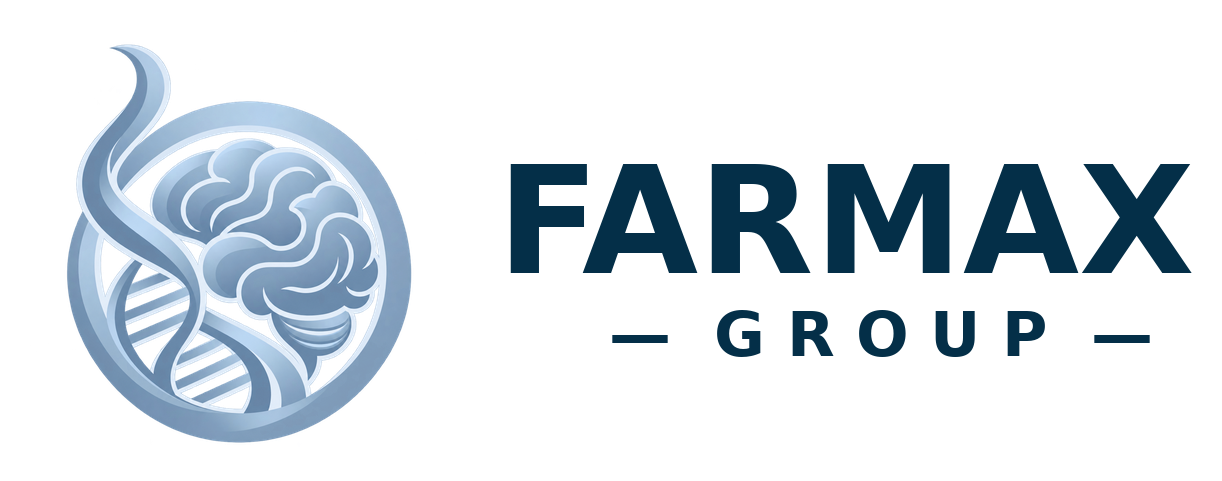
  <div style="font-size:11px; color:#667782; margin-top:5px;">
    © 2026 Maximiliano Hernández S. · CC BY-NC 4.0
  </div>
</div>


<div style="background:#FFF3CD;border-left:10px solid #FF9800;border-radius:6px;padding:14px 18px;margin:10px 0;font-size:1.15em;line-height:1.4;">
<strong>▶️ EJECUTAD ESTA CELDA</strong> &nbsp;·&nbsp; Pulsad el botón <strong>▶</strong> a la izquierda<br/>
<span style="font-size:0.95em;opacity:0.9;">(o <kbd>Mayús</kbd> + <kbd>Enter</kbd>) — esperad a ver el ✅ / la salida debajo</span>
</div>

**Celda final:** estado del notebook (útil si alguien se incorpora tarde).


In [ ]:
# Celda final de estado
print("🏥 Taller IA en salud — notebook V5.2")
print(f"Motor seleccionado: {PROVEEDOR if 'PROVEEDOR' in dir() else '(ejecutad B2)'}")
print(f"Modelo chat: {CHAT_MODEL if 'CHAT_MODEL' in dir() else '—'}")
print(f"Documento RAG: {RUTA_DOCUMENTO if 'RUTA_DOCUMENTO' in dir() else '(aún no definido)'}")
print(f"Modo recuperación: {MODO_RECUPERACION if 'MODO_RECUPERACION' in dir() else '(aún no definido)'}")
print(f"Imagen demo: {RUTA_IMAGEN if 'RUTA_IMAGEN' in dir() else '(aún no definida)'}")
print("Secrets API: GOOGLE_API_KEY/GEMINI_API_KEY · OPENAI_API_KEY · DEEPSEEK_API_KEY")
print("Model secrets OpenAI antiguos: opcionales; V5.2 no depende de ellos.")
print("Mensaje: la IA potencia al profesional, no lo sustituye.")
